In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import ttest_ind

In [34]:
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_excel('./data/cleaned_dataset.xlsx')

# Step 1, Overview of Data and Visualizations

In [35]:
(df.head())


,Unnamed: 0,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,0,1001,Reza,Male,19,Karaj,Alborz,2025-02-19,Vip,17,121.53,2066.01,16,Card,Android,1,3,5
1,1,1002,Sina,Male,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,0,5,3
2,2,1003,Parsa,Male,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,Iphone,1,6,1
3,3,1004,Sina,Male,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,0,4,4
4,4,1005,Kimia,Female,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,1,7,4


In [36]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Unnamed: 0          60 non-null     int64         
 1   customer_id         60 non-null     int64         
 2   first_name          60 non-null     object        
 3   gender              60 non-null     object        
 4   age                 60 non-null     int64         
 5   city                60 non-null     object        
 6   province            60 non-null     object        
 7   signup_date         60 non-null     datetime64[ns]
 8   membership_tier     60 non-null     object        
 9   purchase_count      60 non-null     int64         
 10  avg_order_value     60 non-null     float64       
 11  total_spending      60 non-null     float64       
 12  last_purchase_days  60 non-null     int64         
 13  payment_method      60 non-null     object        
 

In [37]:
(df.describe())


,Unnamed: 0,customer_id,age,signup_date,purchase_count,avg_order_value,total_spending,last_purchase_days,discount_used,returned_items,satisfaction_score
count,60.000000,60.000000,60.00000,60,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,29.500000,1030.500000,43.60000,2023-02-03 14:00:00,17.383333,213.156500,3366.428833,198.600000,0.433333,4.183333,2.983333
min,0.000000,1001.000000,19.00000,2021-02-23 00:00:00,0.000000,27.630000,0.000000,3.000000,0.000000,0.000000,1.000000
25%,14.750000,1015.750000,31.00000,2021-12-06 12:00:00,10.750000,108.137500,1167.035000,134.250000,0.000000,2.000000,2.000000
50%,29.500000,1030.500000,45.00000,2022-08-15 00:00:00,17.000000,165.435000,2128.690000,203.000000,0.000000,4.000000,3.000000
75%,44.250000,1045.250000,58.00000,2024-06-14 12:00:00,24.500000,324.107500,4213.117500,273.750000,1.000000,7.000000,4.000000
max,59.000000,1060.000000,65.00000,2025-09-09 00:00:00,35.000000,449.810000,14354.340000,365.000000,1.000000,8.000000,5.000000
std,17.464249,17.464249,14.15196,NaN,10.149880,130.509923,3235.132979,97.843043,0.499717,2.683861,1.431979


In [38]:
print(df.isna().sum())


Unnamed: 0            0
customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64


In [39]:
print(df.nunique())


Unnamed: 0            60
customer_id           60
first_name            12
gender                 2
age                   35
city                   8
province               8
signup_date           58
membership_tier        4
purchase_count        30
avg_order_value       60
total_spending        60
last_purchase_days    54
payment_method         3
device                 3
discount_used          2
returned_items         9
satisfaction_score     5
dtype: int64


## Visualizing Numerical parameters

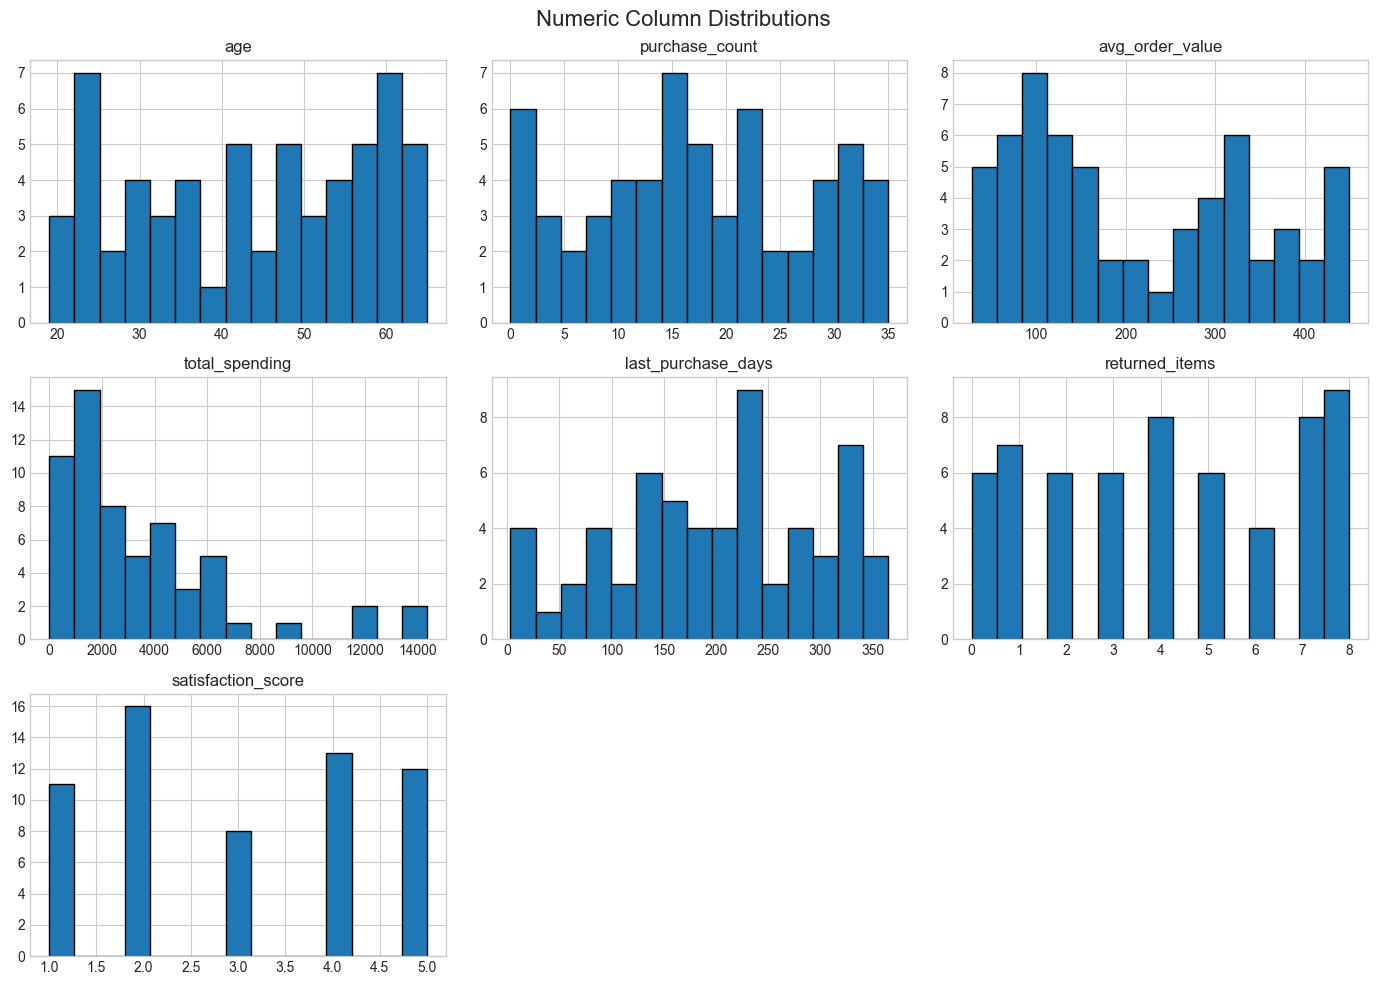

In [123]:
num_cols = ['age', 'purchase_count', 'avg_order_value', 'total_spending',
            'last_purchase_days', 'returned_items', 'satisfaction_score']

df[num_cols].hist(figsize=(14, 10), bins=15, edgecolor='black')
plt.suptitle("Numeric Column Distributions", fontsize=16)
plt.tight_layout()
plt.savefig("charts/Numeric_Column_Distributions.png", dpi=300, bbox_inches="tight")
plt.show()

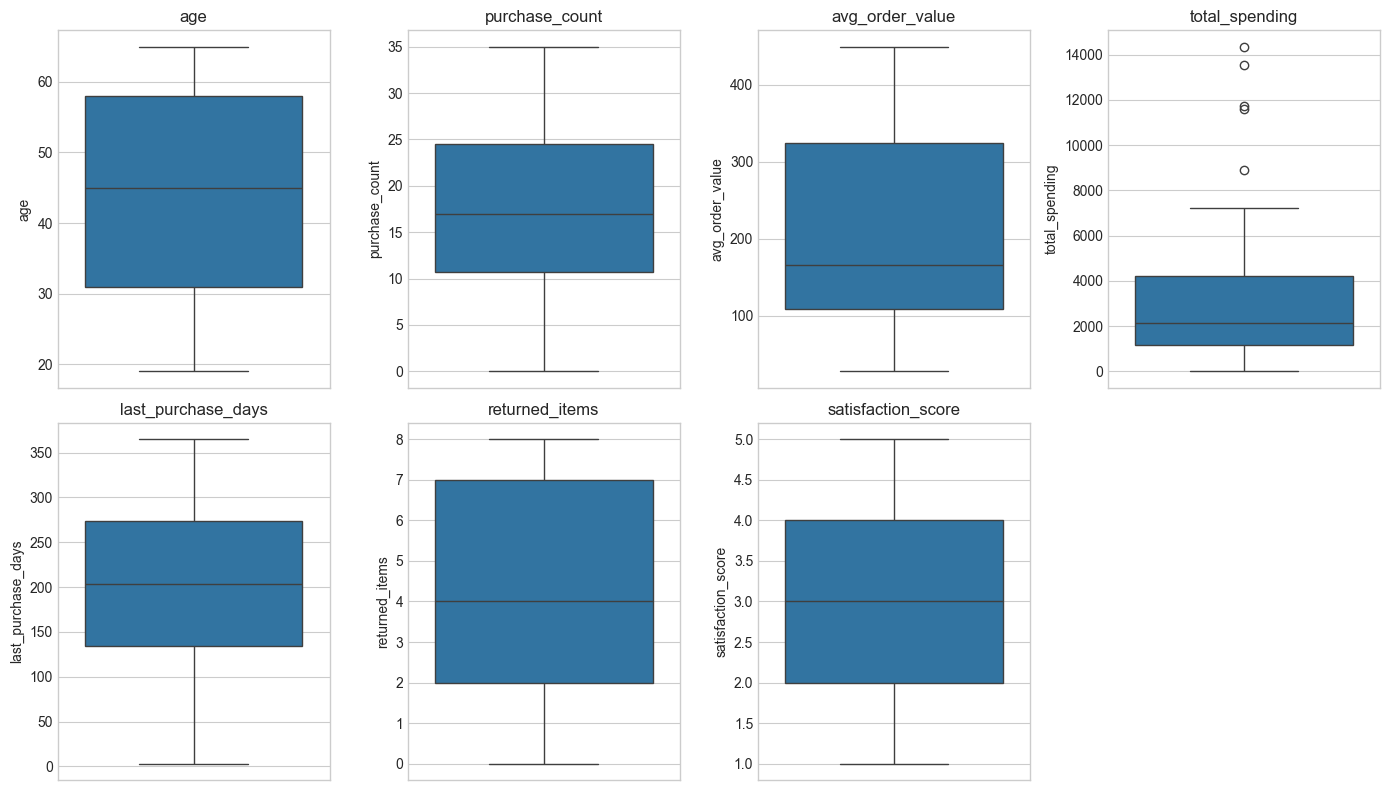

In [41]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


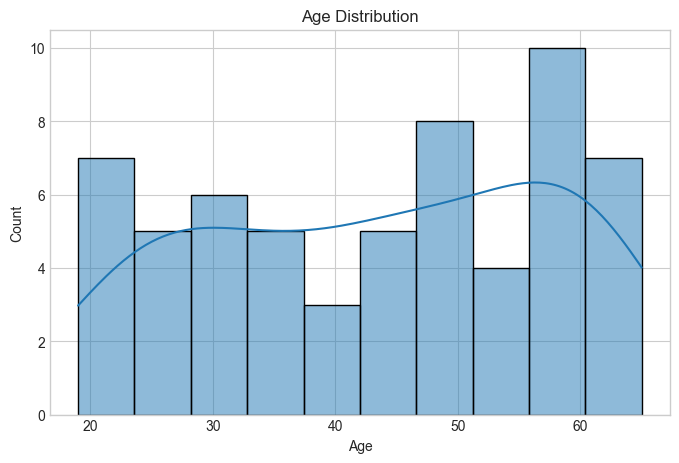

In [125]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("charts/Age_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()


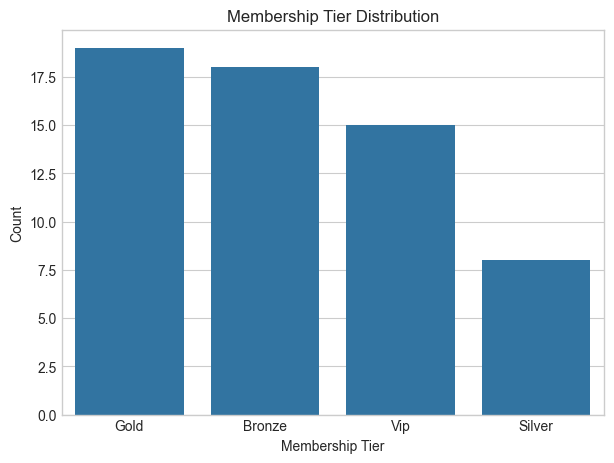

In [124]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='membership_tier', order=df['membership_tier'].value_counts().index)
plt.title("Membership Tier Distribution")
plt.xlabel("Membership Tier")
plt.ylabel("Count")
plt.savefig("charts/Membership_Tier_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

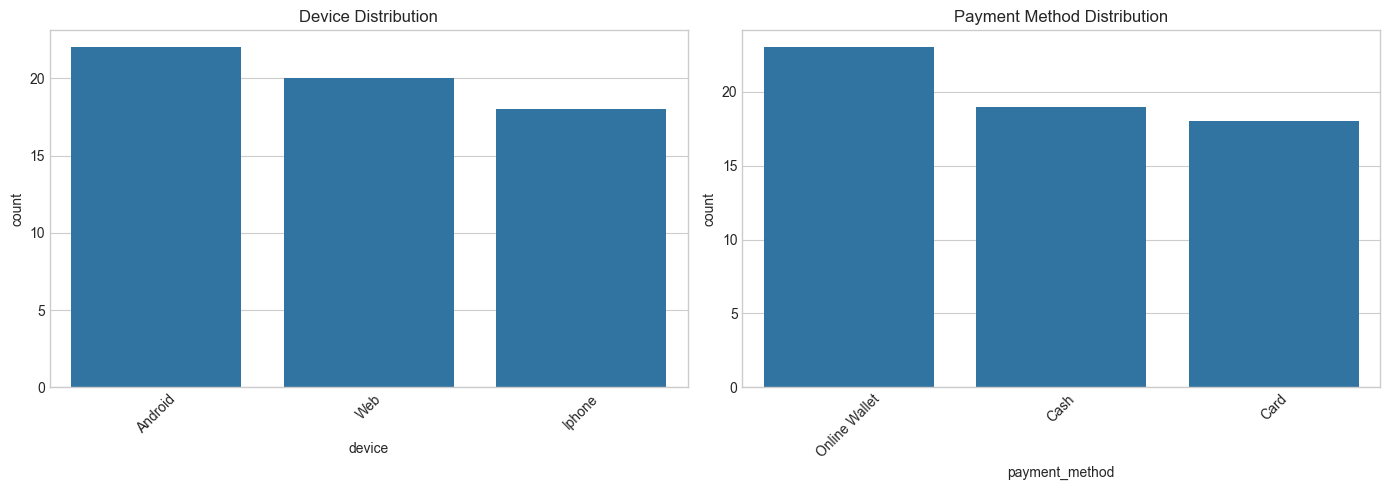

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='device', order=df['device'].value_counts().index, ax=axes[0])
axes[0].set_title("Device Distribution")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='payment_method', order=df['payment_method'].value_counts().index, ax=axes[1])
axes[1].set_title("Payment Method Distribution")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("Device_and_Payment_Method_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# Question 1 : Which customers are most valuable to the company?


In [45]:
from scipy.stats import zscore

df["z_frequency"] = zscore(df["purchase_count"])
df["z_monetary"] = zscore(df["total_spending"])
df["z_recency"] = zscore(df["last_purchase_days"])

In [46]:
df["customer_value"] = (
    -0.3 * df["z_recency"]
    + 0.3 * df["z_frequency"]
    + 0.4 * df["z_monetary"]
)

In [47]:
top_customers = df.sort_values(
    "customer_value",
    ascending=False
)[[
    "customer_id",
    "first_name",
    "purchase_count",
    "total_spending",
    "last_purchase_days",
    "customer_value"
]]

top_customers.head(10)

,customer_id,first_name,purchase_count,total_spending,last_purchase_days,customer_value
56,1057,Maryam,31,13532.74,82,2.033989
43,1044,Mina,33,14354.34,165,1.939407
8,1009,Kimia,34,11615.42,232,1.420544
11,1012,Arash,27,11731.50,224,1.251108
58,1059,Ali,31,8898.55,224,1.017105
3,1004,Sina,23,6121.45,40,1.001318
32,1033,Neda,24,5521.20,112,0.733657
13,1014,Reza,31,3353.89,97,0.718449
49,1050,Reza,30,6198.00,205,0.709326
5,1006,Amir,35,3868.55,205,0.567909


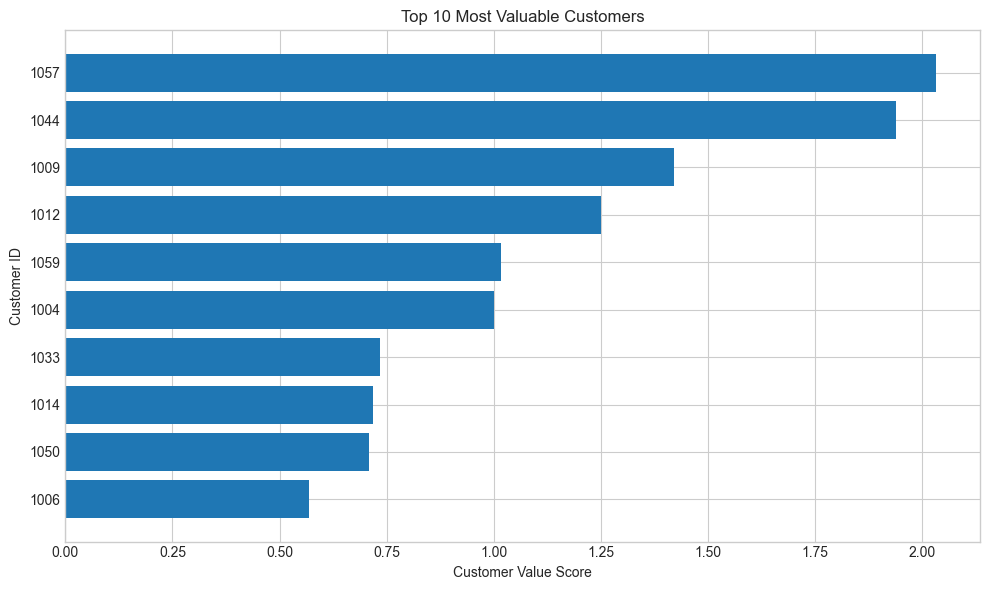

In [127]:
top_10 = (
    df.sort_values("customer_value", ascending=False)
      .head(10)
      .sort_values("customer_value")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["customer_id"].astype(str),
    top_10["customer_value"]
)

plt.xlabel("Customer Value Score")
plt.ylabel("Customer ID")
plt.title("Top 10 Most Valuable Customers")

plt.tight_layout()
plt.savefig("charts/Top_10_Most_Valuable_Customers.png", dpi=300, bbox_inches="tight")
plt.show()

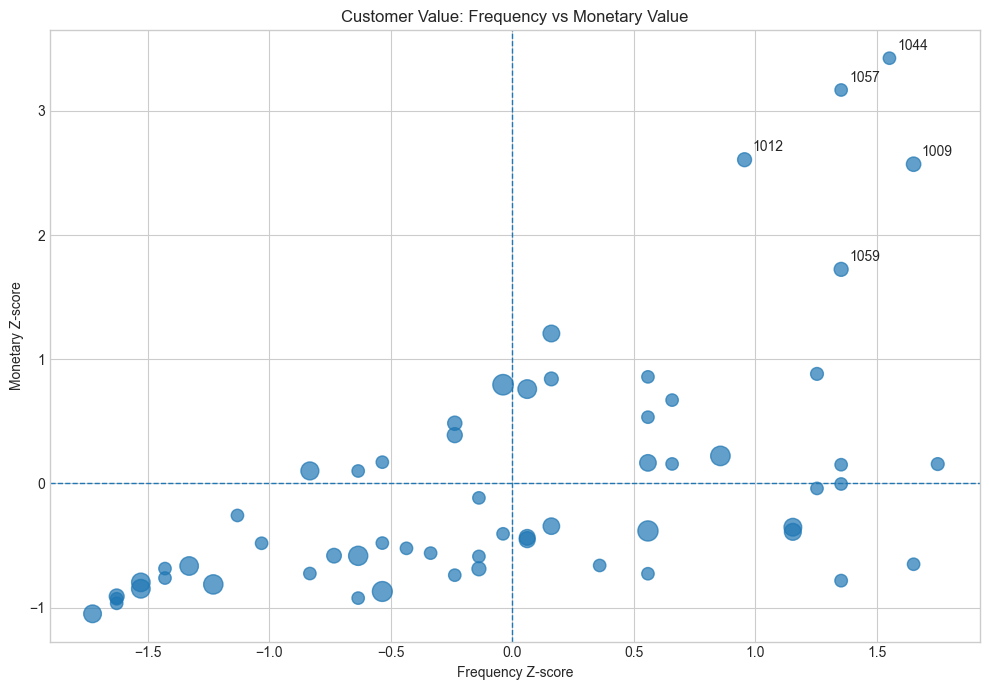

In [128]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df["z_frequency"],
    df["z_monetary"],
    s=(
        df["z_recency"].clip(lower=0) + 1
    ) * 80,
    alpha=0.7
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Frequency Z-score")
plt.ylabel("Monetary Z-score")
plt.title("Customer Value: Frequency vs Monetary Value")

# Label the top 5 customers
top_5 = df.nlargest(5, "customer_value")

for _, row in top_5.iterrows():
    plt.annotate(
        str(row["customer_id"]),
        (row["z_frequency"], row["z_monetary"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.tight_layout()
plt.savefig("charts/Frequency_vs_Monetary_Value.png", dpi=300, bbox_inches="tight")
plt.show()

# Question 2 : Which customers may stop purchasing ?

In [50]:
df["return_rate"] = np.where(
    df["purchase_count"] > 0,
    df["returned_items"] / df["purchase_count"],
    0
)

In [51]:
df["z_dissatisfaction"] = -zscore(
    df["satisfaction_score"]
)

df["z_return_rate"] = zscore(
    df["return_rate"]
)

In [52]:
df["churn_risk_score"] = (
    0.50 * df["z_recency"]
    + 0.25 * df["z_dissatisfaction"]
    + 0.25 * df["z_return_rate"]
)

In [53]:
value_threshold = df["customer_value"].median()
risk_threshold = df["churn_risk_score"].median()

df["value_segment"] = np.where(
    df["customer_value"] >= value_threshold,
    "High Value",
    "Low Value"
)

df["risk_segment"] = np.where(
    df["churn_risk_score"] >= risk_threshold,
    "High Risk",
    "Low Risk"
)

In [54]:
def classify_customer(row):

    if row["value_segment"] == "High Value":
        if row["risk_segment"] == "High Risk":
            return "High Value - High Risk"
        else:
            return "High Value - Low Risk"

    else:
        if row["risk_segment"] == "High Risk":
            return "Low Value - High Risk"
        else:
            return "Low Value - Low Risk"


df["customer_segment"] = df.apply(
    classify_customer,
    axis=1
)

In [55]:
scaler = MinMaxScaler()

df["value_index"] = scaler.fit_transform(
    df[["customer_value"]]
)

df["risk_index"] = scaler.fit_transform(
    df[["churn_risk_score"]]
)

df["revenue_at_risk_index"] = (
    df["value_index"] *
    df["risk_index"]
)

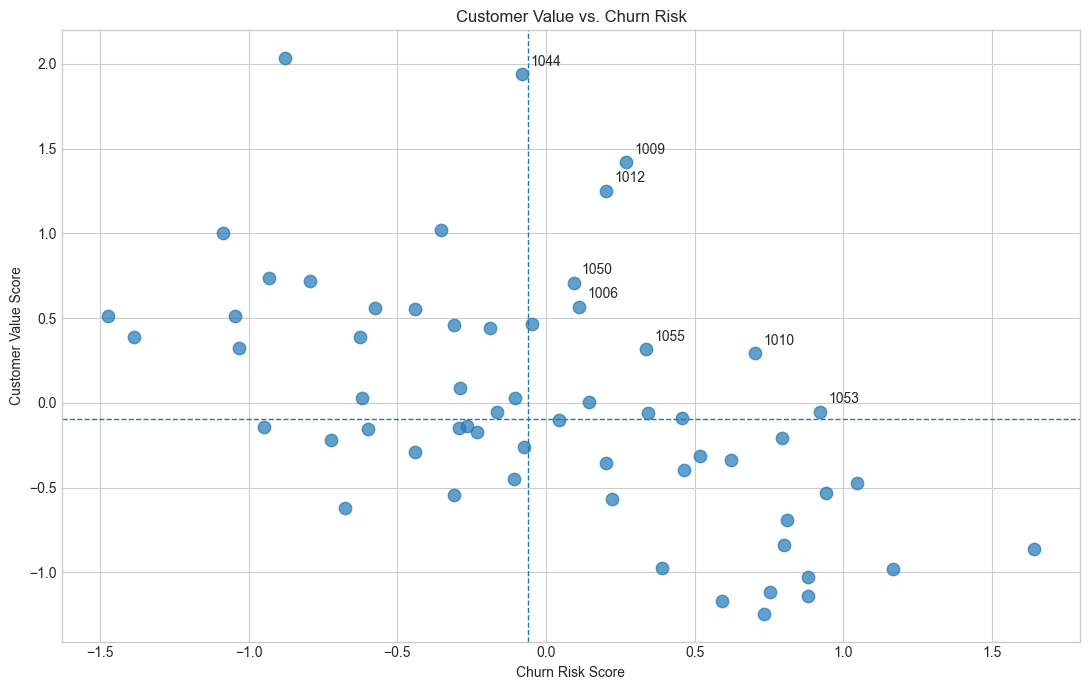

In [129]:
plt.figure(figsize=(11, 7))

plt.scatter(
    df["churn_risk_score"],
    df["customer_value"],
    s=80,
    alpha=0.7
)

risk_median = df["churn_risk_score"].median()
value_median = df["customer_value"].median()

plt.axvline(
    risk_median,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    value_median,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Churn Risk Score")
plt.ylabel("Customer Value Score")

plt.title(
    "Customer Value vs. Churn Risk"
)

# Label the most important customers
priority_customers = df.nlargest(
    8,
    "revenue_at_risk_index"
)

for _, row in priority_customers.iterrows():

    plt.annotate(
        str(row["customer_id"]),
        (
            row["churn_risk_score"],
            row["customer_value"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.tight_layout()
plt.savefig("charts/Customer_Value_vs_Churn_Risk.png", dpi=300, bbox_inches="tight")
plt.show()

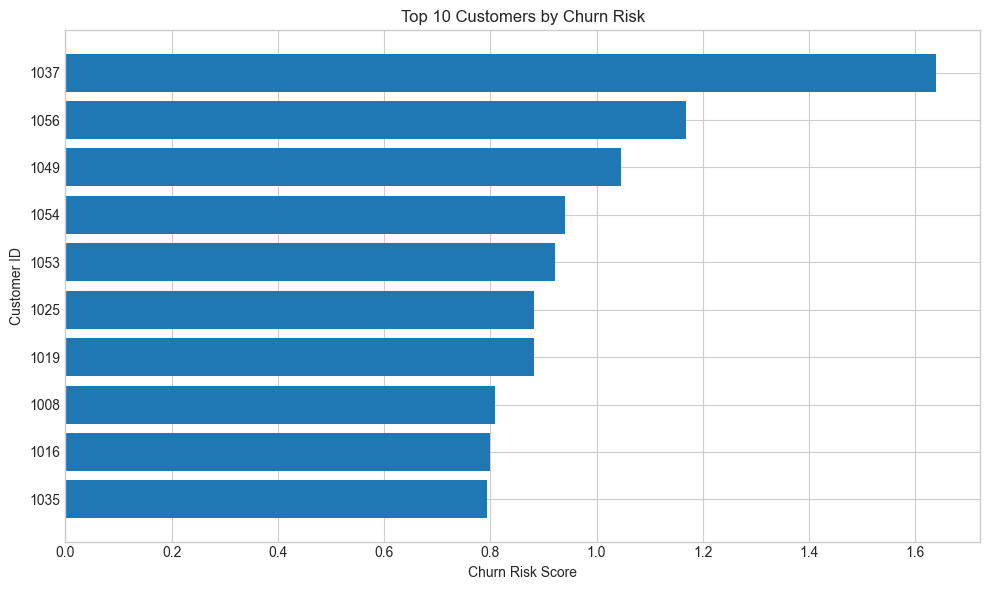

In [130]:
top_risk = df.nlargest(
    10,
    "churn_risk_score"
).sort_values(
    "churn_risk_score"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_risk["customer_id"].astype(str),
    top_risk["churn_risk_score"]
)

plt.xlabel("Churn Risk Score")
plt.ylabel("Customer ID")

plt.title(
    "Top 10 Customers by Churn Risk"
)

plt.tight_layout()
plt.savefig("charts/Top_10_Customers_by_Churn_Risk.png", dpi=300, bbox_inches="tight")
plt.show()

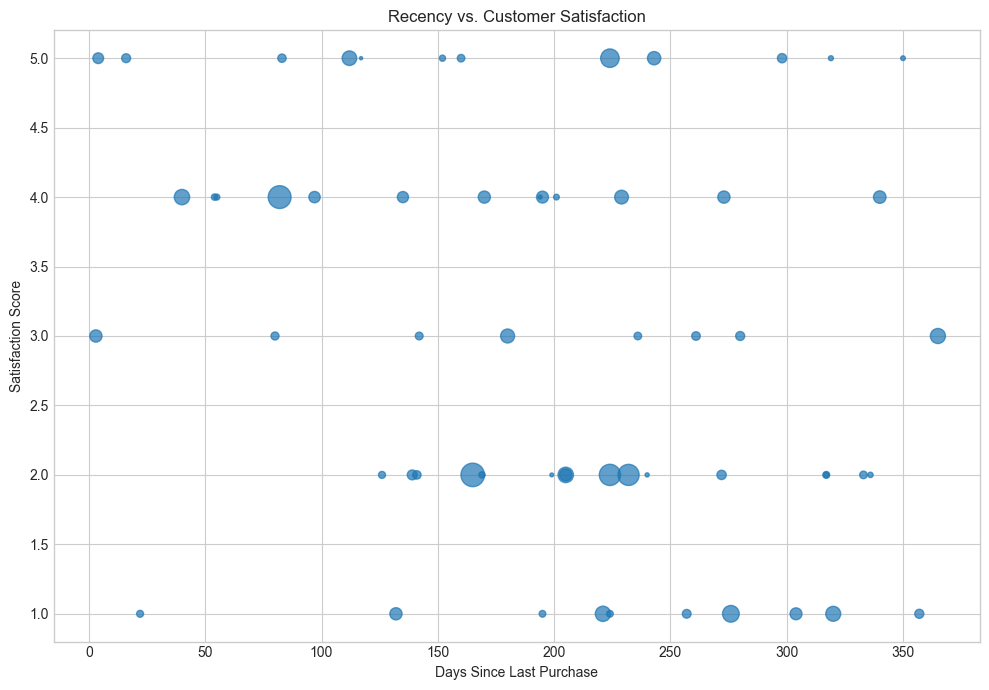

In [131]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["last_purchase_days"],
    df["satisfaction_score"],
    s=df["total_spending"] / 50,
    alpha=0.7
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Satisfaction Score")

plt.title(
    "Recency vs. Customer Satisfaction"
)

plt.tight_layout()
plt.savefig("Recency_vs_Customer_Satisfaction.png", dpi=300, bbox_inches="tight")
plt.show()

# Question 3 : Which city represents the most attractive market for additional advertising investment, considering market size, customer value, engagement, and customer quality?

In [59]:
city_analysis = df.groupby("city").agg(
    customers=("customer_id", "count"),
    
    total_revenue=("total_spending", "sum"),
    
    avg_customer_spending=("total_spending", "mean"),
    
    median_customer_spending=("total_spending", "median"),
    
    avg_order_value=("avg_order_value", "mean"),
    
    avg_purchase_count=("purchase_count", "mean"),
    
    avg_recency=("last_purchase_days", "mean"),
    
    avg_satisfaction=("satisfaction_score", "mean"),
    
    total_returns=("returned_items", "sum"),
    
    total_purchases=("purchase_count", "sum"),
    
    discount_rate=("discount_used", "mean")
).reset_index()

In [61]:
city_analysis["return_ratio"] = np.where(
    city_analysis["total_purchases"] > 0,
    city_analysis["total_returns"] /
    city_analysis["total_purchases"],
    0
)

In [62]:
city_analysis.sort_values(
    "total_revenue",
    ascending=False
)

,city,customers,total_revenue,avg_customer_spending,median_customer_spending,avg_order_value,avg_purchase_count,avg_recency,avg_satisfaction,total_returns,total_purchases,discount_rate,return_ratio
3,Mashhad,11,43197.58,3927.052727,3851.440,210.508182,22.636364,213.636364,2.909091,29,249,0.636364,0.116466
6,Tabriz,12,36192.49,3016.040833,2735.445,238.901667,15.750000,227.250000,3.000000,55,189,0.166667,0.291005
2,Karaj,7,26189.81,3741.401429,2066.010,211.440000,16.000000,166.000000,2.857143,34,112,0.142857,0.303571
0,Ahvaz,8,23384.78,2923.097500,979.365,216.531250,13.875000,171.000000,3.500000,39,111,0.500000,0.351351
1,Isfahan,5,21975.32,4395.064000,3899.420,212.680000,19.800000,177.200000,4.400000,22,99,0.600000,0.222222
5,Shiraz,6,20715.92,3452.653333,1373.265,180.983333,16.333333,214.666667,2.000000,29,98,0.500000,0.295918
4,Rasht,5,15168.54,3033.708000,2237.350,241.554000,16.400000,185.800000,2.600000,22,82,0.400000,0.268293
7,Tehran,6,15161.29,2526.881667,1699.310,172.930000,17.166667,201.000000,2.666667,21,103,0.666667,0.203883


In [63]:
city_analysis.sort_values(
    "avg_recency"
)

,city,customers,total_revenue,avg_customer_spending,median_customer_spending,avg_order_value,avg_purchase_count,avg_recency,avg_satisfaction,total_returns,total_purchases,discount_rate,return_ratio
2,Karaj,7,26189.81,3741.401429,2066.010,211.440000,16.000000,166.000000,2.857143,34,112,0.142857,0.303571
0,Ahvaz,8,23384.78,2923.097500,979.365,216.531250,13.875000,171.000000,3.500000,39,111,0.500000,0.351351
1,Isfahan,5,21975.32,4395.064000,3899.420,212.680000,19.800000,177.200000,4.400000,22,99,0.600000,0.222222
4,Rasht,5,15168.54,3033.708000,2237.350,241.554000,16.400000,185.800000,2.600000,22,82,0.400000,0.268293
7,Tehran,6,15161.29,2526.881667,1699.310,172.930000,17.166667,201.000000,2.666667,21,103,0.666667,0.203883
3,Mashhad,11,43197.58,3927.052727,3851.440,210.508182,22.636364,213.636364,2.909091,29,249,0.636364,0.116466
5,Shiraz,6,20715.92,3452.653333,1373.265,180.983333,16.333333,214.666667,2.000000,29,98,0.500000,0.295918
6,Tabriz,12,36192.49,3016.040833,2735.445,238.901667,15.750000,227.250000,3.000000,55,189,0.166667,0.291005


In [64]:
city_analysis.sort_values(
    "avg_satisfaction",
    ascending=False
)

,city,customers,total_revenue,avg_customer_spending,median_customer_spending,avg_order_value,avg_purchase_count,avg_recency,avg_satisfaction,total_returns,total_purchases,discount_rate,return_ratio
1,Isfahan,5,21975.32,4395.064000,3899.420,212.680000,19.800000,177.200000,4.400000,22,99,0.600000,0.222222
0,Ahvaz,8,23384.78,2923.097500,979.365,216.531250,13.875000,171.000000,3.500000,39,111,0.500000,0.351351
6,Tabriz,12,36192.49,3016.040833,2735.445,238.901667,15.750000,227.250000,3.000000,55,189,0.166667,0.291005
3,Mashhad,11,43197.58,3927.052727,3851.440,210.508182,22.636364,213.636364,2.909091,29,249,0.636364,0.116466
2,Karaj,7,26189.81,3741.401429,2066.010,211.440000,16.000000,166.000000,2.857143,34,112,0.142857,0.303571
7,Tehran,6,15161.29,2526.881667,1699.310,172.930000,17.166667,201.000000,2.666667,21,103,0.666667,0.203883
4,Rasht,5,15168.54,3033.708000,2237.350,241.554000,16.400000,185.800000,2.600000,22,82,0.400000,0.268293
5,Shiraz,6,20715.92,3452.653333,1373.265,180.983333,16.333333,214.666667,2.000000,29,98,0.500000,0.295918


In [65]:
city_analysis.sort_values(
    "return_ratio"
)

,city,customers,total_revenue,avg_customer_spending,median_customer_spending,avg_order_value,avg_purchase_count,avg_recency,avg_satisfaction,total_returns,total_purchases,discount_rate,return_ratio
3,Mashhad,11,43197.58,3927.052727,3851.440,210.508182,22.636364,213.636364,2.909091,29,249,0.636364,0.116466
7,Tehran,6,15161.29,2526.881667,1699.310,172.930000,17.166667,201.000000,2.666667,21,103,0.666667,0.203883
1,Isfahan,5,21975.32,4395.064000,3899.420,212.680000,19.800000,177.200000,4.400000,22,99,0.600000,0.222222
4,Rasht,5,15168.54,3033.708000,2237.350,241.554000,16.400000,185.800000,2.600000,22,82,0.400000,0.268293
6,Tabriz,12,36192.49,3016.040833,2735.445,238.901667,15.750000,227.250000,3.000000,55,189,0.166667,0.291005
5,Shiraz,6,20715.92,3452.653333,1373.265,180.983333,16.333333,214.666667,2.000000,29,98,0.500000,0.295918
2,Karaj,7,26189.81,3741.401429,2066.010,211.440000,16.000000,166.000000,2.857143,34,112,0.142857,0.303571
0,Ahvaz,8,23384.78,2923.097500,979.365,216.531250,13.875000,171.000000,3.500000,39,111,0.500000,0.351351


In [67]:
city_analysis["z_size"] = zscore(
    city_analysis["customers"]
)
city_analysis["z_value"] = zscore(
    city_analysis["avg_customer_spending"]
)
city_analysis["z_satisfaction"] = zscore(
    city_analysis["avg_satisfaction"]
)
city_analysis["z_satisfaction"] = zscore(
    city_analysis["avg_satisfaction"]
)
city_analysis["z_engagement"] = -zscore(
    city_analysis["avg_recency"]
)

In [68]:
city_analysis["market_attractiveness"] = (
    0.30 * city_analysis["z_size"]
    + 0.30 * city_analysis["z_value"]
    + 0.20 * city_analysis["z_engagement"]
    + 0.20 * city_analysis["z_satisfaction"]
)

In [69]:
city_ranking = city_analysis.sort_values(
    "market_attractiveness",
    ascending=False
)

city_ranking[
    [
        "city",
        "customers",
        "total_revenue",
        "avg_customer_spending",
        "avg_recency",
        "avg_satisfaction",
        "market_attractiveness"
    ]
]

,city,customers,total_revenue,avg_customer_spending,avg_recency,avg_satisfaction,market_attractiveness
1,Isfahan,5,21975.32,4395.064000,177.200000,4.400000,0.818670
3,Mashhad,11,43197.58,3927.052727,213.636364,2.909091,0.502469
2,Karaj,7,26189.81,3741.401429,166.000000,2.857143,0.357528
0,Ahvaz,8,23384.78,2923.097500,171.000000,3.500000,0.198506
6,Tabriz,12,36192.49,3016.040833,227.250000,3.000000,0.047583
4,Rasht,5,15168.54,3033.708000,185.800000,2.600000,-0.514676
5,Shiraz,6,20715.92,3452.653333,214.666667,2.000000,-0.628804
7,Tehran,6,15161.29,2526.881667,201.000000,2.666667,-0.781277


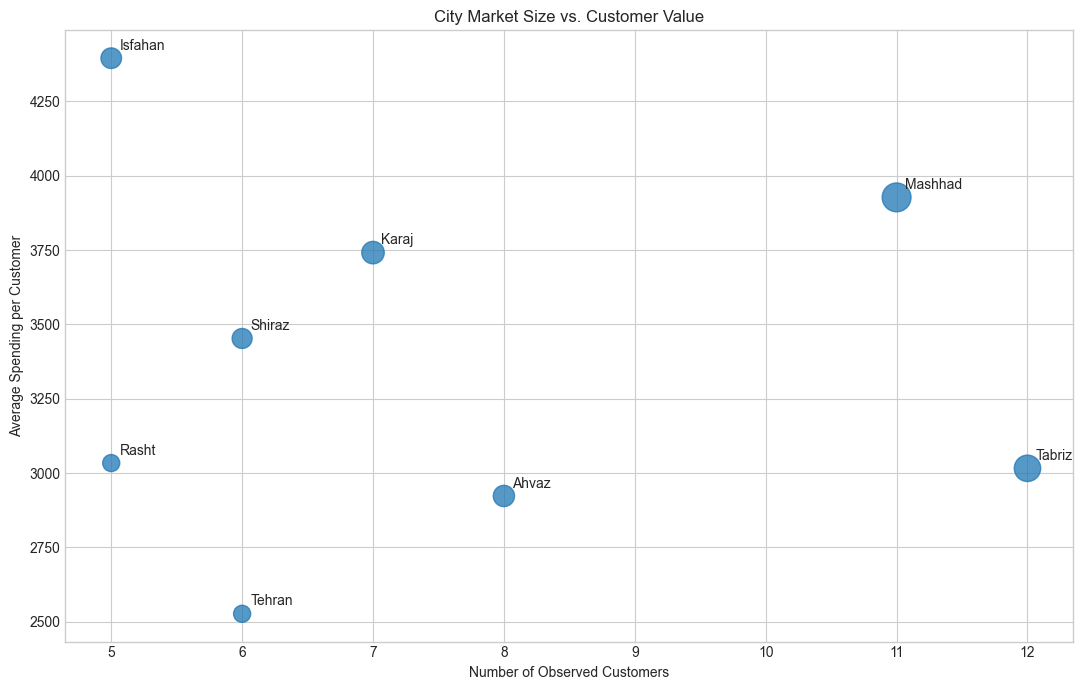

In [132]:

plt.figure(figsize=(11, 7))

plt.scatter(
    city_analysis["customers"],
    city_analysis["avg_customer_spending"],
    s=city_analysis["total_revenue"] / 100,
    alpha=0.75
)

for _, row in city_analysis.iterrows():
    plt.annotate(
        row["city"],
        (
            row["customers"],
            row["avg_customer_spending"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Number of Observed Customers")
plt.ylabel("Average Spending per Customer")

plt.title(
    "City Market Size vs. Customer Value"
)

plt.tight_layout()
plt.savefig("charts/City_Market_Size_vs_Customer_Value.png", dpi=300, bbox_inches="tight")
plt.show()

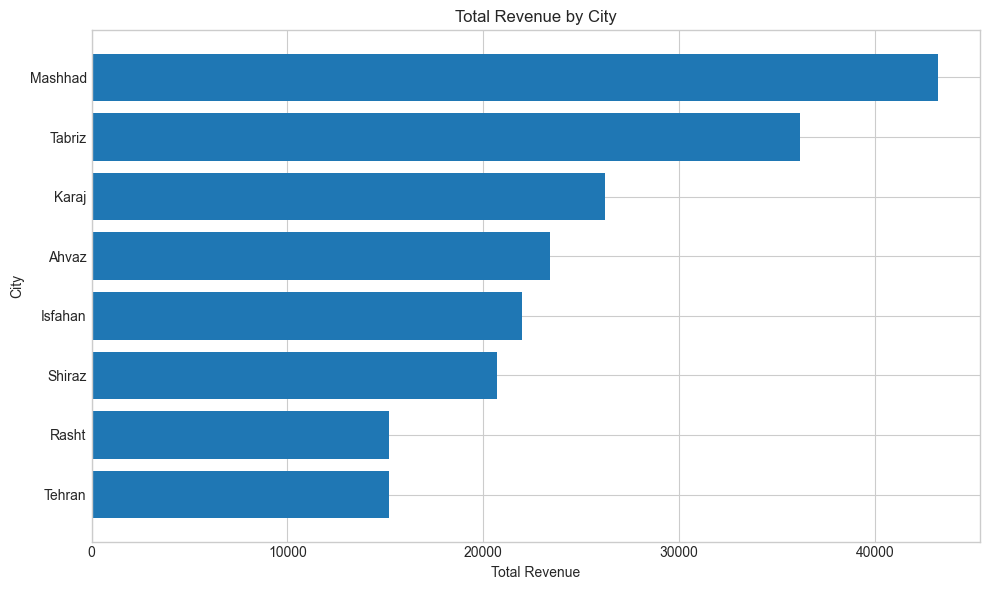

In [133]:
revenue_plot = city_analysis.sort_values(
    "total_revenue"
)

plt.figure(figsize=(10, 6))

plt.barh(
    revenue_plot["city"],
    revenue_plot["total_revenue"]
)

plt.xlabel("Total Revenue")
plt.ylabel("City")

plt.title(
    "Total Revenue by City"
)

plt.tight_layout()
plt.savefig("charts/Total_Revenue_by_City.png", dpi=300, bbox_inches="tight")
plt.show()

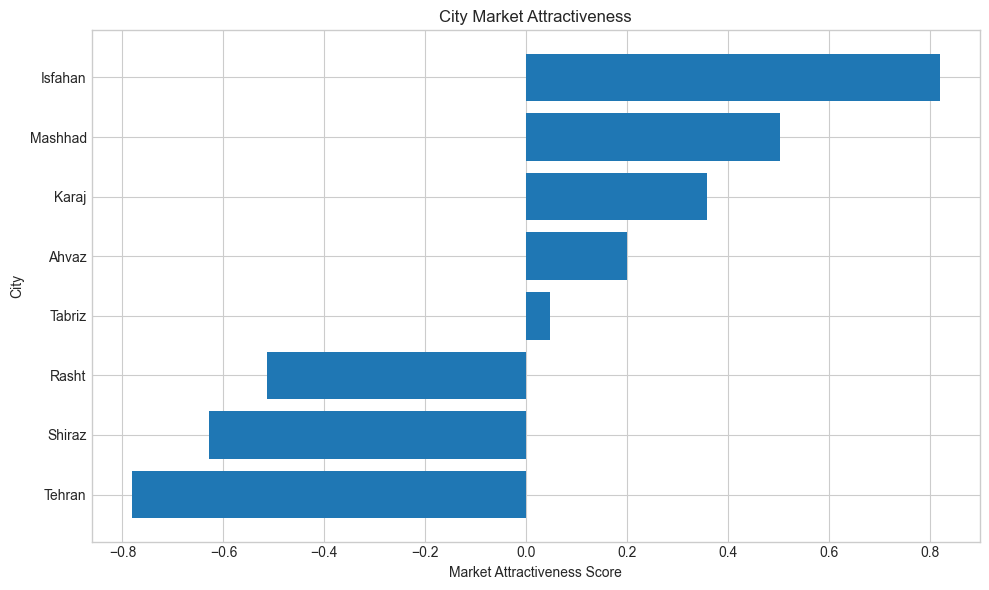

In [134]:
score_plot = city_analysis.sort_values(
    "market_attractiveness"
)

plt.figure(figsize=(10, 6))

plt.barh(
    score_plot["city"],
    score_plot["market_attractiveness"]
)

plt.xlabel("Market Attractiveness Score")
plt.ylabel("City")

plt.title(
    "City Market Attractiveness"
)

plt.tight_layout()
plt.savefig("charts/City_Market_Attractiveness.png", dpi=300, bbox_inches="tight")
plt.show()

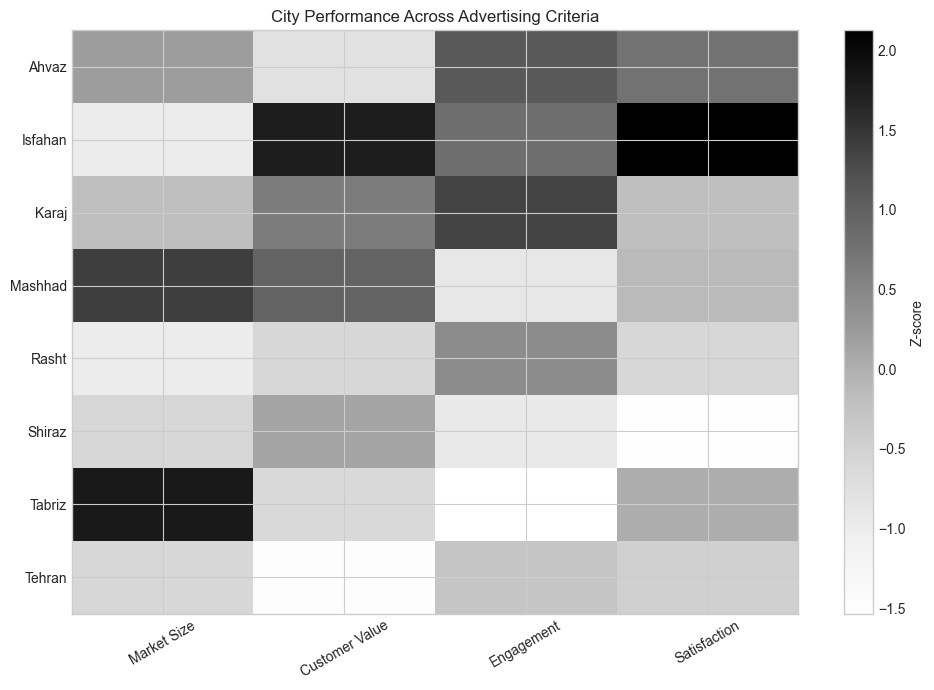

In [136]:
import matplotlib.pyplot as plt

heatmap_data = city_analysis.set_index("city")[
    [
        "z_size",
        "z_value",
        "z_engagement",
        "z_satisfaction"
    ]
]

plt.figure(figsize=(10, 7))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    [
        "Market Size",
        "Customer Value",
        "Engagement",
        "Satisfaction"
    ],
    rotation=30
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.colorbar(
    label="Z-score"
)

plt.title(
    "City Performance Across Advertising Criteria"
)

plt.tight_layout()
plt.savefig("charts/City_Performance_Across_Advertising_Criteria.png", dpi=300, bbox_inches="tight")
plt.show()

## Which City Should Be Prioritized for Advertising?

To identify the most suitable city for additional advertising investment, we did not rely solely on total revenue. A city with high revenue may simply have a larger existing customer base, while a city with a small number of customers may have unusually high spending caused by a few outliers.

Therefore, cities were evaluated across four dimensions: observed customer base size, average customer spending, customer engagement measured through recency, and customer satisfaction. Because these variables have different scales, they were standardized using Z-scores before being combined into a weighted Market Attractiveness Score.

Market size and customer value received the highest weights because the objective is to identify markets that have both an existing customer base and strong economic potential. Engagement and satisfaction were also included because expanding advertising in a market with weak customer engagement or poor customer experience may not produce sustainable growth.

The analysis shows that **Mashhad is the strongest initial candidate for additional advertising investment**. It has the highest total spending in the dataset, with approximately 43,198 in total customer spending across 11 observed customers. Its average spending per customer is also relatively high at approximately 3,927, providing a strong combination of market scale and customer value.

**Isfahan represents an interesting secondary opportunity.** It has the highest average spending per customer, approximately 4,395. However, only five customers from Isfahan are present in the dataset. Therefore, the estimate is less stable and may be strongly affected by individual customers. Rather than immediately allocating a large advertising budget to Isfahan, the company should consider running a smaller controlled campaign to validate the opportunity.

**Tabriz has the largest observed customer base, with 12 customers, but its average spending per customer is lower than Mashhad and Isfahan.** This suggests that Tabriz may be a good market for scaling customer acquisition, but the company should investigate whether lower customer value can be improved through better targeting, product recommendations, or promotional strategies.

An important limitation is that the dataset does not contain advertising costs, impressions, clicks, conversions, customer acquisition costs, or incremental revenue. Therefore, the analysis cannot directly estimate advertising ROI or prove that one city will generate more profit from advertising than another. Instead, it identifies the cities with the strongest existing customer signals and uses those signals to prioritize where marketing experiments should be conducted.

### Business Recommendation

The company should prioritize **Mashhad as the primary market for additional advertising**, while using **Isfahan as a smaller experimental market** and evaluating **Tabriz as a potential scale market**. Future advertising campaigns should be measured using conversion rate, customer acquisition cost, incremental revenue, and ultimately profit rather than relying only on historical customer spending.



# Question 4: Were Discounts Actually Useful?


In [76]:
# Check discount usage distribution
df["discount_used"].value_counts()


discount_used
0    34
1    26
Name: count, dtype: int64

In [77]:
# Compare customer behavior by discount usage
discount_analysis = df.groupby("discount_used").agg(
    customers=("customer_id", "count"),
    total_revenue=("total_spending", "sum"),
    avg_spending=("total_spending", "mean"),
    median_spending=("total_spending", "median"),
    avg_order_value=("avg_order_value", "mean"),
    avg_purchases=("purchase_count", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    avg_returns=("returned_items", "mean")
).round(2)

discount_analysis


,customers,total_revenue,avg_spending,median_spending,avg_order_value,avg_purchases,avg_satisfaction,avg_returns
discount_used,,,,,,,,
0,34,127049.20,3736.74,2751.72,220.70,17.29,2.76,4.26
1,26,74936.53,2882.17,1945.17,203.29,17.50,3.27,4.08


In [78]:
# Rename index labels for readability
discount_analysis_readable = discount_analysis.rename(
    index={
        0: "No Discount",
        1: "Discount"
    }
)

discount_analysis_readable


,customers,total_revenue,avg_spending,median_spending,avg_order_value,avg_purchases,avg_satisfaction,avg_returns
discount_used,,,,,,,,
No Discount,34,127049.20,3736.74,2751.72,220.70,17.29,2.76,4.26
Discount,26,74936.53,2882.17,1945.17,203.29,17.50,3.27,4.08


In [79]:
# Calculate average metrics for discount and non-discount groups
discount_group = df[df["discount_used"] == 1]
no_discount_group = df[df["discount_used"] == 0]


In [80]:
# Calculate differences between groups
spending_diff = (
    discount_group["total_spending"].mean()
    - no_discount_group["total_spending"].mean()
)

aov_diff = (
    discount_group["avg_order_value"].mean()
    - no_discount_group["avg_order_value"].mean()
)

purchase_diff = (
    discount_group["purchase_count"].mean()
    - no_discount_group["purchase_count"].mean()
)

satisfaction_diff = (
    discount_group["satisfaction_score"].mean()
    - no_discount_group["satisfaction_score"].mean()
)

returns_diff = (
    discount_group["returned_items"].mean()
    - no_discount_group["returned_items"].mean()
)


In [81]:
# Show metric differences
pd.DataFrame({
    "metric": [
        "total_spending",
        "avg_order_value",
        "purchase_count",
        "satisfaction_score",
        "returned_items"
    ],
    "difference_discount_minus_no_discount": [
        spending_diff,
        aov_diff,
        purchase_diff,
        satisfaction_diff,
        returns_diff
    ]
}).round(2)


,metric,difference_discount_minus_no_discount
0,total_spending,-854.57
1,avg_order_value,-17.41
2,purchase_count,0.21
3,satisfaction_score,0.50
4,returned_items,-0.19


In [82]:
# Calculate percentage differences
percentage_diff = pd.DataFrame({
    "metric": [
        "total_spending",
        "avg_order_value",
        "purchase_count",
        "satisfaction_score",
        "returned_items"
    ],
    "discount_mean": [
        discount_group["total_spending"].mean(),
        discount_group["avg_order_value"].mean(),
        discount_group["purchase_count"].mean(),
        discount_group["satisfaction_score"].mean(),
        discount_group["returned_items"].mean()
    ],
    "no_discount_mean": [
        no_discount_group["total_spending"].mean(),
        no_discount_group["avg_order_value"].mean(),
        no_discount_group["purchase_count"].mean(),
        no_discount_group["satisfaction_score"].mean(),
        no_discount_group["returned_items"].mean()
    ]
})

percentage_diff["percentage_difference"] = (
    (
        percentage_diff["discount_mean"]
        - percentage_diff["no_discount_mean"]
    )
    / percentage_diff["no_discount_mean"]
) * 100

percentage_diff.round(2)


,metric,discount_mean,no_discount_mean,percentage_difference
0,total_spending,2882.17,3736.74,-22.87
1,avg_order_value,203.29,220.70,-7.89
2,purchase_count,17.50,17.29,1.19
3,satisfaction_score,3.27,2.76,18.25
4,returned_items,4.08,4.26,-4.40


In [83]:
# Calculate return-to-purchase ratio
df["return_ratio"] = np.where(
    df["purchase_count"] > 0,
    df["returned_items"] / df["purchase_count"],
    0
)


In [84]:
# Compare return ratio by discount usage
df.groupby("discount_used").agg(
    customers=("customer_id", "count"),
    avg_return_ratio=("return_ratio", "mean"),
    median_return_ratio=("return_ratio", "median")
).round(3)


,customers,avg_return_ratio,median_return_ratio
discount_used,,,
0,34,0.454,0.224
1,26,0.709,0.279


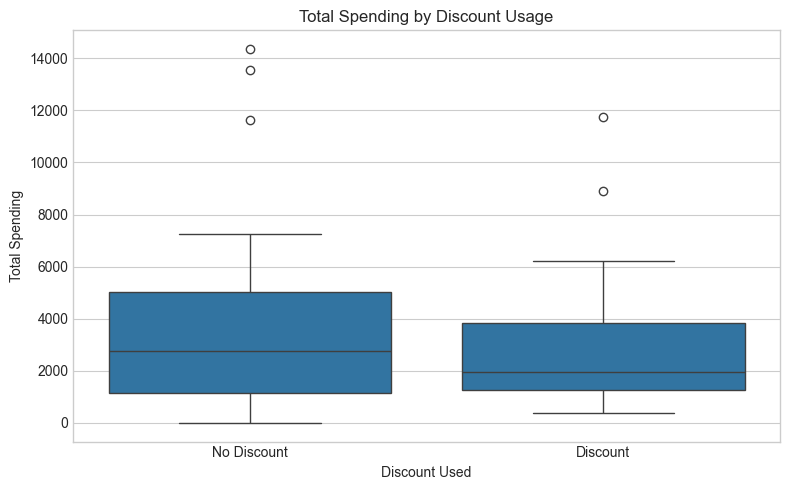

In [137]:
# Compare total spending distribution by discount usage
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="discount_used",
    y="total_spending"
)

plt.xticks(
    [0, 1],
    ["No Discount", "Discount"]
)

plt.title("Total Spending by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.savefig("charts/Total_Spending_by_Discount_Usage.png", dpi=300, bbox_inches="tight")
plt.show()


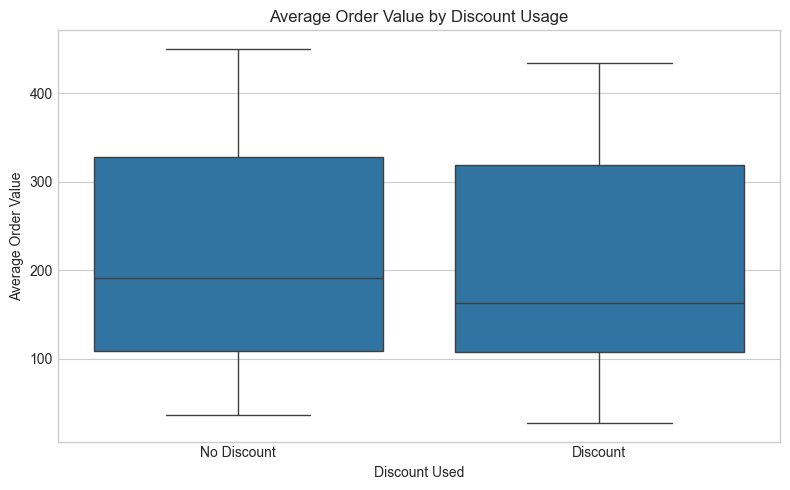

In [138]:
# Compare average order value by discount usage
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="discount_used",
    y="avg_order_value"
)

plt.xticks(
    [0, 1],
    ["No Discount", "Discount"]
)

plt.title("Average Order Value by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.savefig("charts/Average_Order_Value_by_Discount_Usage.png", dpi=300, bbox_inches="tight")
plt.show()


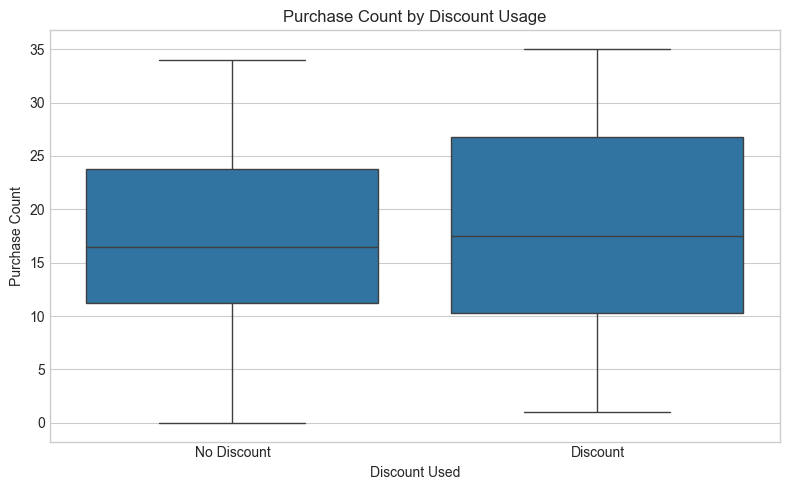

In [139]:
# Compare purchase count by discount usage
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="discount_used",
    y="purchase_count"
)

plt.xticks(
    [0, 1],
    ["No Discount", "Discount"]
)

plt.title("Purchase Count by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Purchase Count")

plt.tight_layout()
plt.savefig("charts/Purchase_Count_by_Discount_Usage.png", dpi=300, bbox_inches="tight")
plt.show()


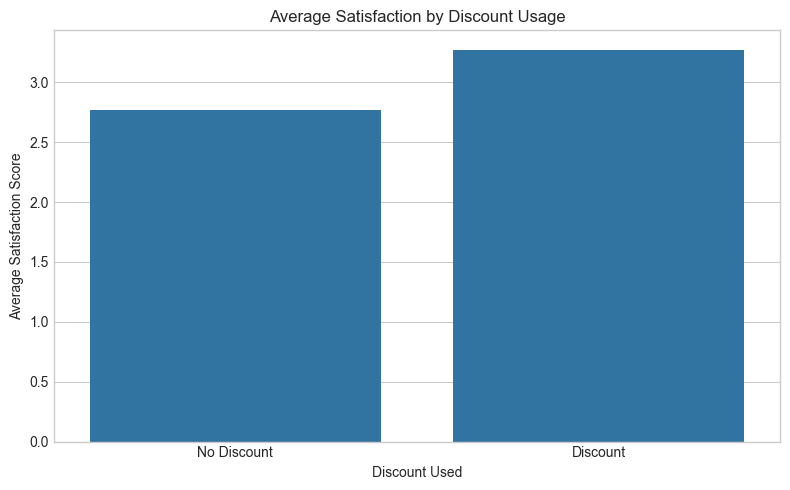

In [140]:
# Compare customer satisfaction by discount usage
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="discount_used",
    y="satisfaction_score",
    errorbar=None
)

plt.xticks(
    [0, 1],
    ["No Discount", "Discount"]
)

plt.title("Average Satisfaction by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Satisfaction Score")

plt.tight_layout()
plt.savefig("charts/Average_Satisfaction_by_Discount_Usage.png", dpi=300, bbox_inches="tight")
plt.show()


In [89]:
# Create final discount comparison table
final_discount_table = df.groupby("discount_used").agg(
    customers=("customer_id", "count"),
    total_revenue=("total_spending", "sum"),
    avg_spending=("total_spending", "mean"),
    median_spending=("total_spending", "median"),
    avg_order_value=("avg_order_value", "mean"),
    avg_purchases=("purchase_count", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    avg_return_ratio=("return_ratio", "mean")
).round(2)

final_discount_table = final_discount_table.rename(
    index={
        0: "No Discount",
        1: "Discount"
    }
)

final_discount_table


,customers,total_revenue,avg_spending,median_spending,avg_order_value,avg_purchases,avg_satisfaction,avg_return_ratio
discount_used,,,,,,,,
No Discount,34,127049.20,3736.74,2751.72,220.70,17.29,2.76,0.45
Discount,26,74936.53,2882.17,1945.17,203.29,17.50,3.27,0.71


In [91]:
# Run Welch's t-test for total spending
ttest_ind(
    discount_group["total_spending"],
    no_discount_group["total_spending"],
    equal_var=False
)


TtestResult(statistic=np.float64(-1.0530491048264683), pvalue=np.float64(0.29668647405110476), df=np.float64(57.991905300845545))

In [94]:
value_threshold = df["customer_value"].median()

df["value_segment"] = np.where(
    df["customer_value"] >= value_threshold,
    "High Value",
    "Low Value"
)

In [96]:
# Compare discount performance within customer value segments
segment_discount_analysis = df.groupby(
    ["value_segment", "discount_used"]
).agg(
    customers=("customer_id", "count"),
    avg_spending=("total_spending", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_purchases=("purchase_count", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    avg_return_ratio=("return_ratio", "mean")
).round(2)

segment_discount_analysis


customers  avg_spending  avg_order_value  \
value_segment discount_used                                             
High Value    0                     18       5675.07           241.28   
              1                     12       4410.59           176.76   
Low Value     0                     16       1556.12           197.55   
              1                     14       1572.10           226.03   

                             avg_purchases  avg_satisfaction  avg_return_ratio  
value_segment discount_used                                                     
High Value    0                      23.83              3.17              0.22  
              1                      25.75              3.08              0.15  
Low Value     0                       9.94              2.31              0.72  
              1                      10.43              3.43              1.19

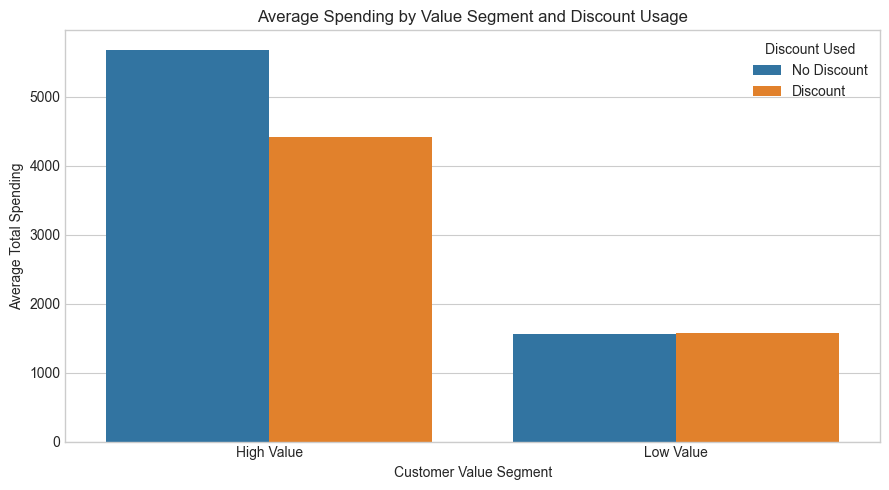

In [141]:
# Compare average spending by value segment and discount usage
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="value_segment",
    y="total_spending",
    hue="discount_used",
    errorbar=None
)

plt.title("Average Spending by Value Segment and Discount Usage")
plt.xlabel("Customer Value Segment")
plt.ylabel("Average Total Spending")
plt.legend(
    title="Discount Used",
    labels=["No Discount", "Discount"]
)

plt.tight_layout()
plt.savefig("charts/Average_Spending_by_Value_Segment_and_Discount_Usage.png", dpi=300, bbox_inches="tight")
plt.show()



The purpose of this analysis is to determine whether offering discounts was actually beneficial for the company. More specifically, we want to know whether customers who received discounts generated more revenue, purchased more frequently, placed larger orders, and showed better customer satisfaction than customers who did not use discounts.

The dataset contains a binary variable called `discount_used`, where:

* `0` represents customers who did not use a discount.
* `1` represents customers who used a discount.

Instead of evaluating discounts using revenue alone, we compare the two groups across several dimensions: total spending, average order value, purchase frequency, customer satisfaction, and return behavior.

---

## 1. Comparing Discounted and Non-Discounted Customers

The first step was to divide customers into two groups and calculate the main performance indicators for each group.

The analysis showed the following differences:

| Metric                   | Discount Used | No Discount |
| ------------------------ | ------------: | ----------: |
| Average Spending         |      2,882.17 |    3,736.74 |
| Average Order Value      |        203.29 |      220.70 |
| Average Purchases        |         17.50 |       17.29 |
| Satisfaction             |          3.27 |        2.76 |
| Return-to-Purchase Ratio |          0.71 |        0.45 |

The most important result is that **customers who did not use discounts generated substantially more spending on average**.

Average spending was approximately:

[
3736.74
]

for non-discounted customers, compared with:

[
2882.17
]

for discounted customers.

This represents an observed difference of approximately:

[
\frac{3736.74-2882.17}{3736.74}\times100
\approx22.87%
]

Therefore, customers in the discount group spent approximately **22.87% less on average** than customers who did not use discounts.

The median spending showed the same general pattern, which is important because it suggests that the difference is not simply caused by a small number of extreme customers.

---

## 2. Did Discounts Increase Purchase Frequency?

One possible justification for discounts is that they may encourage customers to purchase more frequently.

However, the difference in purchase frequency was extremely small.

Discounted customers made an average of:

[
17.50
]

purchases, while non-discounted customers made:

[
17.29
]

purchases.

The difference is only:

[
17.50-17.29=0.21
]

purchases per customer.

Therefore, the data does **not** provide strong evidence that discounts substantially increased purchasing frequency.

This is an important finding because although discounted customers purchased slightly more frequently, the increase was too small to compensate for their considerably lower average spending.

In other words:

> Discounts may have encouraged slightly more frequent purchases, but they did not generate a meaningful increase in overall customer spending.

---

## 3. Did Discounts Increase Order Value?

Another possible benefit of discounts would be encouraging customers to place larger orders.

However, the average order value was actually lower among discounted customers.

The average order value was:

* **203.29** for customers using discounts
* **220.70** for customers without discounts

Therefore, customers receiving discounts did not place larger orders on average.

This suggests that the discounts were not successfully encouraging customers to spend more per transaction.

From a business perspective, this is important because a discount can increase the number of transactions while simultaneously reducing the amount of money collected from each transaction.

---

## 4. Did Discounts Improve Customer Satisfaction?

The strongest positive result associated with discounts was customer satisfaction.

Discounted customers had an average satisfaction score of:

[
3.27
]

while non-discounted customers had an average score of:

[
2.76
]

This represents an improvement of approximately:

[
\frac{3.27-2.76}{2.76}\times100
\approx18.5%
]

Therefore, customers who used discounts reported noticeably higher satisfaction.

This suggests that discounts may have a positive role in **customer engagement and customer experience**, even though they did not appear to increase spending.

However, we should be careful when interpreting this result. A higher satisfaction score does not necessarily mean that the discount itself caused the improvement.

For example, the company may have offered discounts to customers as part of special campaigns or loyalty programs, which could themselves influence satisfaction.

---

## 5. What About Product Returns?

Returns provide another important dimension of the analysis.

The average number of returned items was slightly lower among discounted customers. However, when returns are considered relative to purchase frequency, the situation becomes less favorable.

The return-to-purchase ratio was approximately:

[
0.71
]

for discounted customers compared with:

[
0.45
]

for customers without discounts.

This means that discounted customers returned a larger proportion of their purchases.

Therefore, although the absolute number of returned items was not necessarily higher, the return behavior relative to purchasing activity suggests a potential problem.

From a business perspective, this matters because returns can create additional costs through:

* reverse logistics,
* refund processing,
* inventory handling,
* product inspection,
* and potentially lost revenue.

Therefore, a discount strategy should not be evaluated only by the amount of revenue generated. The company should also consider the additional operational costs associated with returns.

---

# 6. Looking at Customer Value Segments

The overall comparison becomes even more useful when customers are separated according to their value to the company.

This is important because a discount may have very different effects on a high-value customer and a low-value customer.

## High-Value Customers

Among high-value customers, those who used discounts showed:

* lower average spending,
* lower average order value,
* only slightly higher purchase frequency,
* and no meaningful improvement in satisfaction.

This suggests that discounts may be particularly inefficient for high-value customers.

These customers are already generating substantial revenue, so reducing their prices may simply decrease the amount of money the company receives without producing a significant change in their behavior.

For these customers, the company may obtain better results from **non-price incentives**, such as:

* VIP benefits,
* free shipping,
* early access to new products,
* loyalty rewards,
* personalized recommendations,
* exclusive products,
* or priority customer service.

The goal should be to increase retention and loyalty without unnecessarily reducing the customer's willingness to pay.

---

## Low-Value Customers

The results are more interesting for low-value customers.

For this segment, discounts produced some positive signals:

* average spending increased slightly,
* average order value increased by approximately 14.4%,
* and customer satisfaction increased substantially.

This suggests that discounts may be more useful for **activating or encouraging low-value customers**.

However, the overall spending difference was relatively small, while the return-to-purchase ratio increased.

Therefore, discounts may have some value as a targeted activation mechanism, but they should not be applied automatically to every low-value customer.

Instead, the company should identify customers who are:

* low-value,
* inactive,
* recently becoming less engaged,
* or potentially at risk of leaving,

and then test whether a targeted discount changes their behavior.

---

# 7. Why Can We Not Say That Discounts Caused These Results?

This is one of the most important statistical limitations of the analysis.

The dataset is observational.

Customers were not randomly assigned to receive or not receive a discount.

Therefore, we cannot conclude:

> "Discounts caused customers to spend 22.87% less."

The correct interpretation is:

> "Customers who used discounts spent 22.87% less on average than customers who did not use discounts."

These are very different statements.

There may be other variables influencing both discount usage and spending.

For example, the company might intentionally give discounts to:

* inactive customers,
* customers with lower spending,
* customers at risk of churn,
* new customers,
* or customers who need an incentive to purchase.

In this situation, the lower spending of discounted customers may exist **before** the discount was given.

This creates a potential selection bias.

Therefore:

[
Correlation \neq Causation
]

The observed relationship between discount usage and spending should not be interpreted as a causal effect.

---

# 8. Overall Interpretation

Looking at all the metrics together, discounts do **not** appear to be an effective universal strategy for increasing revenue.

The main findings are:

1. **Discounted customers generated lower average spending.**
2. **Their average order value was also lower.**
3. **Purchase frequency was almost identical between the two groups.**
4. **Customer satisfaction was higher among discounted customers.**
5. **The return-to-purchase ratio was higher among discounted customers.**
6. **Discounts appeared more promising for low-value customers than for high-value customers.**

Therefore, discounts appear to function more effectively as a **customer engagement and activation tool** than as a general revenue-growth mechanism.

---

# 9. Business Recommendation

Based on the analysis, the company should **not distribute discounts universally**.

Instead, discounts should be targeted toward specific customer segments where there is a clear business reason to use them.

### Recommendation 1 — Target At-Risk and Low-Value Customers

Discounts can be used selectively to reactivate customers who have become inactive or whose engagement is declining.

The objective should not simply be to give them a lower price, but to create an incentive for them to return and make another purchase.

---

### Recommendation 2 — Avoid Unnecessary Discounts for High-Value Customers

High-value customers should generally not receive automatic price reductions.

Instead, the company should use benefits that increase loyalty without directly reducing revenue per order.

Examples include:

* VIP membership benefits,
* free shipping,
* early access,
* loyalty points,
* personalized offers,
* and exclusive products.

This can help preserve customer value while maintaining retention.

---

### Recommendation 3 — Evaluate Discounts Using Incremental Profit

The company should not judge a discount campaign based only on revenue or number of purchases.

A successful discount should generate **incremental profit** after accounting for:

* the discount itself,
* additional purchases,
* customer acquisition or retention costs,
* returns,
* logistics,
* and other operational expenses.

A campaign that increases revenue but reduces profit should not be considered successful.

---

# 10. How Should the Company Measure the True Effect of Discounts?

The best next step would be to run a controlled A/B test.

Customers with similar characteristics could be randomly divided into two groups:

### Control Group

No discount.

### Treatment Group

Receives a specific discount.

The company could then compare:

* Conversion Rate
* Average Order Value
* Purchase Frequency
* Incremental Revenue
* Incremental Profit
* Return Rate
* Customer Retention
* Customer Satisfaction

The key metric should be:

[
Incremental\ Profit
===================

## Profit_{Discount}

Profit_{Control}
]

rather than simply comparing total revenue.

Randomization would make the two groups more comparable and would provide much stronger evidence about whether the discount itself caused a change in customer behavior.

---

# Final Conclusion

The analysis does not provide evidence that discounts are an effective universal method for increasing sales. Customers who used discounts actually showed lower average spending and lower average order value, while their purchase frequency was almost unchanged.

The main positive effect associated with discounts was higher customer satisfaction. However, discounted customers also showed a higher return-to-purchase ratio, which may create additional costs for the company.

Therefore, the most appropriate strategy is **targeted discounting rather than universal discounting**.

Discounts should primarily be tested as a tool for activating low-value or potentially at-risk customers. High-value customers should generally be managed through personalized loyalty benefits rather than direct price reductions.

Finally, because the current analysis is observational, the company should not interpret the observed differences as causal effects. A randomized A/B test should be conducted to determine the true incremental impact of discounts on revenue, profit, retention, and returns.

**Business Decision: Discounts are potentially useful as a targeted customer-engagement tool, but the current data does not justify using them as a general sales-growth strategy.**


# Question 5: What Actions Should the Company Take to Increase Sales?


In [100]:
# Copy data
customers = df.copy()

# Customers who never purchased
customers["never_purchased"] = customers["purchase_count"] == 0

# Z-scores
customers["z_recency"] = -(
    customers["last_purchase_days"]
    - customers["last_purchase_days"].mean()
) / customers["last_purchase_days"].std()

customers["z_frequency"] = (
    customers["purchase_count"]
    - customers["purchase_count"].mean()
) / customers["purchase_count"].std()

customers["z_monetary"] = (
    customers["total_spending"]
    - customers["total_spending"].mean()
) / customers["total_spending"].std()

In [101]:
customers["rfm_score"] = (
    0.30 * customers["z_recency"]
    + 0.30 * customers["z_frequency"]
    + 0.40 * customers["z_monetary"]
)

In [102]:
active_cutoff = customers["last_purchase_days"].median()
value_cutoff = customers["total_spending"].median()
frequency_cutoff = customers["purchase_count"].median()

In [103]:
def classify_customer(row):

    if row["purchase_count"] == 0:
        return "Never Purchased"

    high_value = (
        row["total_spending"] >= value_cutoff
    )

    high_frequency = (
        row["purchase_count"] >= frequency_cutoff
    )

    recent = (
        row["last_purchase_days"] <= active_cutoff
    )

    if high_value and high_frequency and recent:
        return "Champions"

    elif high_value and not recent:
        return "At Risk"

    elif high_value and recent:
        return "Loyal / High Value"

    elif not high_value and recent:
        return "Low Value Active"

    else:
        return "Low Value Inactive"

In [105]:
customers["segment"] = customers.apply(
    classify_customer,
    axis=1
)

In [106]:
at_risk = customers[
    customers["segment"] == "At Risk"
].sort_values(
    "total_spending",
    ascending=False
)

at_risk[
    [
        "customer_id",
        "city",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score",
        "discount_used"
    ]
]

,customer_id,city,purchase_count,total_spending,last_purchase_days,satisfaction_score,discount_used
11,1012,Mashhad,27,11731.50,224,2,1
8,1009,Karaj,34,11615.42,232,2,0
58,1059,Isfahan,31,8898.55,224,5,1
9,1010,Karaj,19,7241.47,276,1,0
49,1050,Mashhad,30,6198.00,205,2,1
54,1055,Rasht,19,6068.22,221,1,0
34,1035,Tabriz,17,5918.21,365,3,0
52,1053,Tehran,18,5805.54,320,1,1
45,1046,Tabriz,15,4923.45,229,4,0
31,1032,Isfahan,15,4615.05,243,5,0


In [107]:
at_risk.sort_values(
    "satisfaction_score"
)

,Unnamed: 0,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,...,value_segment,risk_segment,customer_segment,value_index,risk_index,revenue_at_risk_index,return_ratio,never_purchased,rfm_score,segment
9,9,1010,Arash,Male,55,Karaj,Alborz,2022-06-25,Silver,19,...,High Value,High Risk,High Value - High Risk,0.468788,0.699034,0.327698,0.368421,False,0.289585,At Risk
54,54,1055,Mina,Female,62,Rasht,Gilan,2024-02-20,Bronze,19,...,High Value,High Risk,High Value - High Risk,0.476037,0.581017,0.276586,0.000000,False,0.313159,At Risk
52,52,1053,Sina,Male,32,Tehran,Tehran,2021-11-08,Gold,18,...,High Value,High Risk,High Value - High Risk,0.363612,0.769323,0.279735,0.333333,False,-0.052424,At Risk
53,53,1054,Reza,Male,59,Tabriz,East Azerbaijan,2021-03-26,Gold,9,...,Low Value,High Risk,Low Value - High Risk,0.216508,0.775337,0.167867,0.777778,False,-0.530772,At Risk
48,48,1049,Ali,Male,32,Mashhad,Khorasan,2023-01-02,Gold,23,...,Low Value,High Risk,Low Value - High Risk,0.234811,0.809389,0.190053,0.043478,False,-0.471256,At Risk
49,49,1050,Reza,Male,48,Mashhad,Khorasan,2023-08-04,Bronze,30,...,High Value,High Risk,High Value - High Risk,0.596043,0.502831,0.299709,0.066667,False,0.703390,At Risk
5,5,1006,Amir,Male,58,Mashhad,Khorasan,2022-01-26,Gold,35,...,High Value,High Risk,High Value - High Risk,0.552917,0.508404,0.281105,0.142857,False,0.563156,At Risk
8,8,1009,Kimia,Female,61,Karaj,Alborz,2021-05-14,Silver,34,...,High Value,High Risk,High Value - High Risk,0.812929,0.559872,0.455136,0.235294,False,1.408656,At Risk
10,10,1011,Neda,Female,41,Karaj,Alborz,2021-12-16,Bronze,19,...,Low Value,High Risk,Low Value - High Risk,0.283302,0.639691,0.181226,0.421053,False,-0.313573,At Risk
11,11,1012,Arash,Male,51,Mashhad,Khorasan,2023-07-22,Gold,27,...,High Value,High Risk,High Value - High Risk,0.761260,0.537542,0.409210,0.111111,False,1.240638,At Risk


In [109]:
low_value_active = customers[
    customers["segment"] == "Low Value Active"
].sort_values(
    "avg_order_value"
)

In [111]:
customers["inactivity_score"] = (
    customers["last_purchase_days"]
    - customers["last_purchase_days"].min()
) / (
    customers["last_purchase_days"].max()
    - customers["last_purchase_days"].min()
)

customers["value_score"] = (
    customers["total_spending"]
    - customers["total_spending"].min()
) / (
    customers["total_spending"].max()
    - customers["total_spending"].min()
)

customers["retention_opportunity"] = (
    0.6 * customers["value_score"]
    + 0.4 * customers["inactivity_score"]
)

In [112]:
customers.sort_values(
    "retention_opportunity",
    ascending=False
)[
    [
        "customer_id",
        "total_spending",
        "last_purchase_days",
        "retention_opportunity"
    ]
].head(10)

,customer_id,total_spending,last_purchase_days,retention_opportunity
43,1044,14354.34,165,0.779006
8,1009,11615.42,232,0.738554
11,1012,11731.50,224,0.734566
56,1057,13532.74,82,0.652951
34,1035,5918.21,365,0.647376
58,1059,8898.55,224,0.616151
9,1010,7241.47,276,0.604345
52,1053,5805.54,320,0.592943
29,1030,4079.14,340,0.542880
54,1055,6068.22,221,0.494531


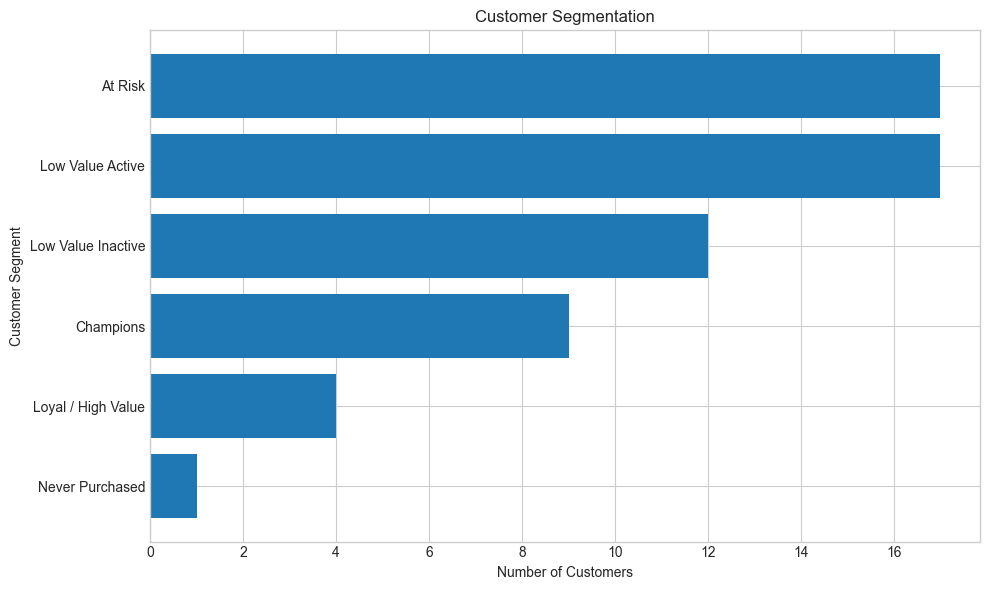

In [142]:

segment_counts = (
    customers["segment"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    segment_counts.index,
    segment_counts.values
)

plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.title("Customer Segmentation")

plt.tight_layout()
plt.savefig("charts/Customer_Segmentation.png", dpi=300, bbox_inches="tight")
plt.show()

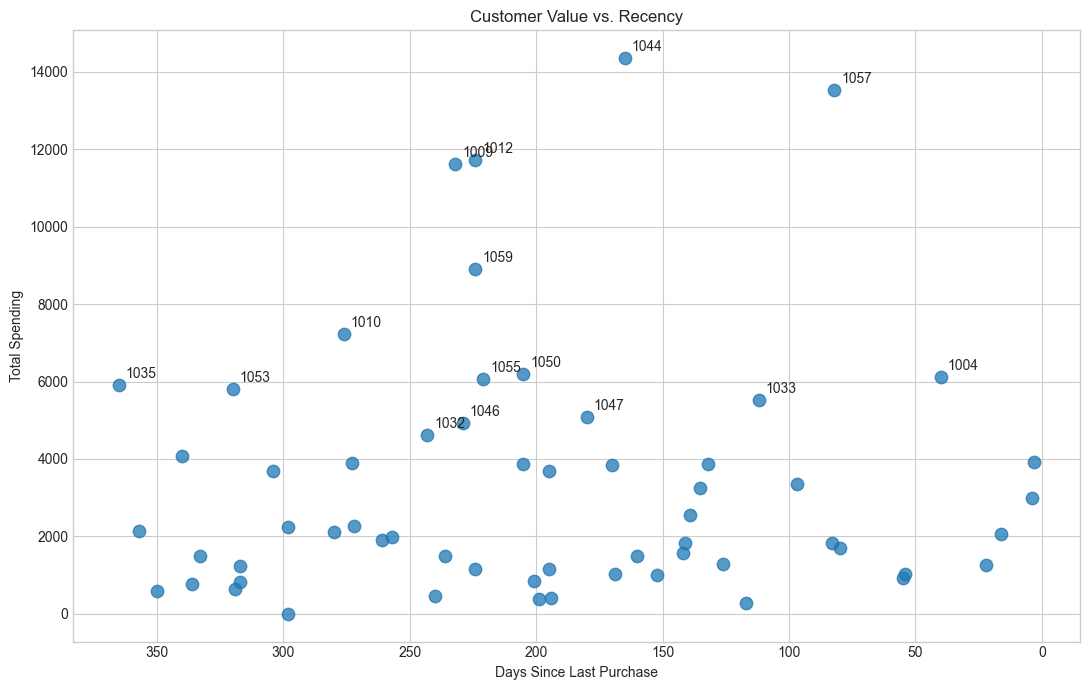

In [143]:
plt.figure(figsize=(11, 7))

plt.scatter(
    customers["last_purchase_days"],
    customers["total_spending"],
    s=80,
    alpha=0.75
)

for _, row in customers.iterrows():
    if row["total_spending"] > customers["total_spending"].quantile(0.75):
        plt.annotate(
            str(row["customer_id"]),
            (
                row["last_purchase_days"],
                row["total_spending"]
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.title("Customer Value vs. Recency")

plt.gca().invert_xaxis()

plt.tight_layout()
plt.savefig("charts/Customer_Value_vs_Recency.png", dpi=300, bbox_inches="tight")
plt.show()

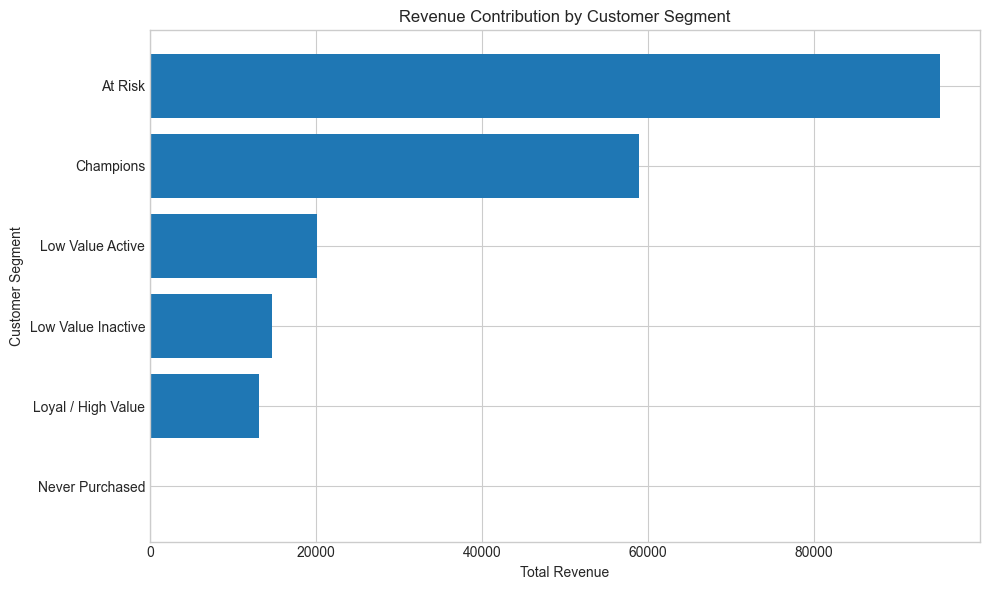

In [144]:
segment_revenue = (
    customers
    .groupby("segment")["total_spending"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    segment_revenue.index,
    segment_revenue.values
)

plt.xlabel("Total Revenue")
plt.ylabel("Customer Segment")
plt.title("Revenue Contribution by Customer Segment")

plt.tight_layout()
plt.savefig("charts/Revenue_Contribution_by_Customer_Segment.png", dpi=300, bbox_inches="tight")
plt.show()

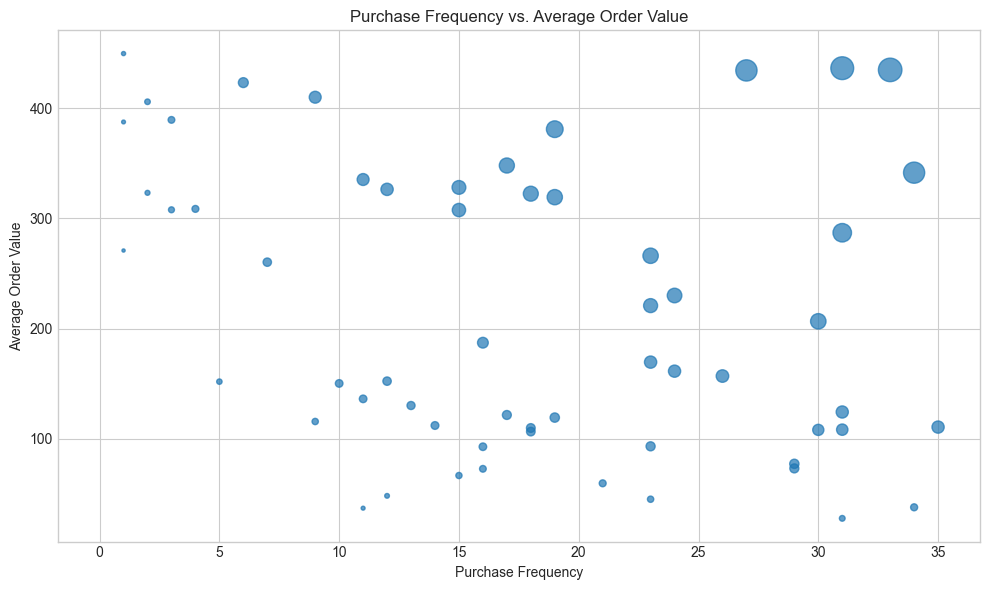

In [145]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customers["purchase_count"],
    customers["avg_order_value"],
    s=customers["total_spending"] / 50,
    alpha=0.7
)

plt.xlabel("Purchase Frequency")
plt.ylabel("Average Order Value")

plt.title(
    "Purchase Frequency vs. Average Order Value"
)

plt.tight_layout()
plt.savefig("charts/Purchase_Frequency_vs_Average_Order_Value.png", dpi=300, bbox_inches="tight")
plt.show()

## From Customer Analysis to Business Recommendations

The objective of this analysis is not simply to identify which customers spend more or which customers are inactive. The main goal is to translate customer behavior into practical business actions that can increase revenue while protecting customer value and profitability.

To achieve this, several customer-level indicators were combined, including total spending, purchase frequency, average order value, recency, satisfaction, return behavior, discount usage, customer value, customer risk, RFM score, and retention opportunity.

This approach allows the company to move from descriptive analysis to actionable customer segmentation.

The analysis identified three major opportunities:

1. **Retain high-value customers who are at risk of becoming inactive.**
2. **Increase the value of active customers through upselling and cross-selling.**
3. **Use customer and geographic characteristics to make advertising more targeted.**

---

# 1. Protect High-Value Revenue Through a Targeted Win-Back Strategy

The most immediate opportunity is the group of customers classified as **At Risk**.

The analysis identified 17 customers in the At Risk segment. However, these customers should not be treated equally. Some of them have generated substantially more revenue than others, meaning that losing certain customers would have a much larger financial impact on the company.

For example, several high-value customers have both substantial historical spending and a long period since their last purchase.

Some particularly important examples include:

* Customer 1012: 11,731.50 total spending and 224 days since the last purchase
* Customer 1009: 11,615.42 total spending and 232 days since the last purchase
* Customer 1010: 7,241.47 total spending and 276 days since the last purchase
* Customer 1050: 6,198.00 total spending and 205 days since the last purchase
* Customer 1035: 5,918.21 total spending and 365 days since the last purchase
* Customer 1053: 5,805.54 total spending and 320 days since the last purchase

These customers have already demonstrated significant historical value. Therefore, the company should prioritize retaining or reactivating them rather than treating them as ordinary inactive customers.

---

## Retention Opportunity Score

To prioritize customers within the At Risk group, a retention opportunity index was created using customer value and inactivity.

The idea is:

[
Retention\ Opportunity
======================

0.6(Value\ Score)
+
0.4(Inactivity\ Score)
]

A higher score indicates a customer who represents a combination of high historical value and significant inactivity.

The highest-scoring customers in the analysis include:

* Customer 1044 — Retention Opportunity: 0.779
* Customer 1009 — 0.739
* Customer 1012 — 0.735
* Customer 1057 — 0.653
* Customer 1035 — 0.647
* Customer 1059 — 0.616
* Customer 1010 — 0.604
* Customer 1053 — 0.593
* Customer 1030 — 0.543
* Customer 1055 — 0.495

This ranking is useful because it transforms a large list of potentially risky customers into a prioritized action list.

For example, Customer 1044 has generated the highest total spending in the dataset, at 14,354.34. Although the customer purchased relatively recently compared with some other at-risk customers, the customer's extremely high historical value makes retention particularly important.

Customer 1035 is another interesting case. The customer has generated 5,918.21 in total spending but has not purchased for 365 days. This represents a much more severe inactivity problem.

Therefore, the company should consider both value and inactivity rather than using recency alone.

---

## Recommended Win-Back Strategy

The company should not send the same message or incentive to all 17 At Risk customers.

Instead, the customers should be prioritized into tiers.

### Tier 1: Very High-Value At-Risk Customers

These customers should receive highly personalized retention efforts.

Possible actions include:

* Personalized product recommendations
* VIP treatment
* Loyalty rewards
* Early access to new products
* Free shipping
* Personalized customer service
* Targeted incentives

Direct discounts should not automatically be the first option.

This is especially important because the previous discount analysis showed that discounts did not produce a clear increase in overall spending. Therefore, using discounts indiscriminately could reduce revenue without necessarily changing customer behavior.

### Tier 2: Medium-Value At-Risk Customers

These customers can receive automated but personalized reactivation campaigns.

For example:

* Email reminders
* Recommended products
* Loyalty points
* Free-shipping offers
* Limited-time personalized promotions

### Tier 3: Low-Value At-Risk Customers

The company should use low-cost automated campaigns for these customers.

Spending significant marketing resources on customers with low historical value may not be economically efficient.

---

# 2. Use Customer Satisfaction to Improve Retention

The analysis also shows that customer value alone is not enough to determine the correct action.

For example, some high-value At Risk customers have low satisfaction scores.

Customer 1012 has:

* Total spending: 11,731.50
* Purchase count: 27
* Last purchase: 224 days ago
* Satisfaction: 2
* Discount used: Yes

Customer 1009 has:

* Total spending: 11,615.42
* Purchase count: 34
* Last purchase: 232 days ago
* Satisfaction: 2
* Discount used: No

These customers are particularly interesting because their historical value is very high, but their satisfaction is relatively low.

For such customers, simply sending another discount may not solve the underlying problem.

The company should investigate whether the inactivity is related to:

* Product quality
* Delivery problems
* Customer service
* Product expectations
* Returns
* Overall shopping experience

This leads to an important business principle:

> **Not every at-risk customer needs a discount; some customers need a better experience.**

---

# 3. Increase Revenue Through Upselling and Cross-Selling

The second major recommendation is to increase the value of customers who are still active.

The previous discount analysis showed that discounts did not substantially increase purchase frequency or average order value. Therefore, simply lowering prices is not necessarily an effective strategy for increasing sales.

Instead, the company should focus on increasing:

[
Average\ Order\ Value
]

and:

[
Revenue\ per\ Customer
]

through:

* Cross-selling
* Product bundles
* Personalized recommendations
* Complementary products
* Free-shipping thresholds
* Loyalty rewards

The target group should be customers who are active but have relatively low average order values.

These customers are attractive because they already demonstrate purchasing behavior. The company does not need to convince them to return; it needs to increase the value of their existing transactions.

For example, if a customer normally spends 180 per order, a personalized recommendation or bundle could encourage the customer to purchase additional complementary products.

This is preferable to simply offering a 20% discount because a discount reduces the amount paid by the customer, while an effective cross-selling strategy can increase the total transaction value.

---

# 4. Do Not Treat Discounts as a Universal Sales Strategy

The discount analysis provides an important constraint on the recommendations.

Customers who used discounts had lower average total spending than customers who did not use discounts:

[
2882.17
\quad vs. \quad
3736.74
]

This represents an observed difference of approximately 22.87%.

Average order value was also slightly lower for discounted customers, while purchase frequency was almost identical.

Therefore, the data does not support the idea that the company should simply increase the number of discounts offered.

However, discounts may still have a role.

The previous analysis showed that discounts were associated with higher satisfaction and appeared to be more useful for some lower-value customers.

Therefore, the appropriate strategy is:

> **Use discounts selectively rather than universally.**

For example, discounts may be tested for inactive or low-value customers where the objective is reactivation, while high-value customers may be better served through personalized loyalty benefits.

---

# 5. Geographic Marketing Strategy

The third opportunity is geographic targeting.

The customer data shows that the company has customers across several cities, but these markets do not have identical customer value.

### Mashhad

Mashhad is an important market because it contains several high-value customers.

Examples include:

* Customer 1012 — 11,731.50
* Customer 1050 — 6,198.00
* Customer 1030 — 4,079.14
* Customer 1006 — 3,868.55

This suggests that Mashhad is not only a market with customers, but a market containing customers with substantial observed spending.

Therefore, Mashhad should be considered a strong candidate for a larger targeted marketing campaign.

However, the company should not simply increase advertising expenditure without measurement.

The campaign should be tested against a control group or comparable market and evaluated using incremental revenue and incremental profit.

---

## Isfahan

Isfahan is also interesting because several customers have relatively high spending and satisfaction.

For example:

* Customer 1059 — 8,898.55 spending, satisfaction 5
* Customer 1032 — 4,615.05 spending, satisfaction 5
* Customer 1005 — 3,899.42 spending, satisfaction 4

This suggests potentially strong customer value in Isfahan.

However, the number of observed customers is relatively small. Therefore, the estimated average customer value in this city is less statistically stable.

The appropriate strategy is therefore not to immediately allocate a large budget to Isfahan, but to run a smaller pilot campaign.

If the pilot produces strong conversion and incremental profit, the company can scale the campaign.

---

## Tabriz

Tabriz has a relatively large customer presence and several high-value customers, but the market also contains customers with relatively low satisfaction and high return ratios.

For example, Customer 1035 has:

* Total spending: 5,918.21
* Last purchase: 365 days ago
* Satisfaction: 3
* Return ratio: approximately 0.29

Customer 1054 has:

* Total spending: 3,691.44
* Last purchase: 304 days ago
* Satisfaction: 1
* Return ratio: approximately 0.78

This suggests that simply spending more on acquisition in Tabriz may not be sufficient.

The company should also investigate customer experience and product-return problems before significantly increasing advertising expenditure.

---

# 6. Prioritize Opportunities Using Revenue at Risk

Another useful metric in this analysis is the Revenue at Risk Index.

This metric combines customer value and risk to estimate how important a potentially lost customer is to the business.

This is particularly useful for management because not every risky customer represents the same financial threat.

For example:

A customer with:

[
Total\ Spending = 10,000
]

and high inactivity represents a much larger financial opportunity than a customer with:

[
Total\ Spending = 500
]

and the same inactivity.

Therefore, management should prioritize:

[
High\ Value + High\ Risk
]

before:

[
Low\ Value + High\ Risk
]

This allows the marketing budget to be allocated according to potential financial impact rather than simply the number of inactive customers.

---

# 7. Three Final Business Recommendations

Based on the complete analysis, the company should implement the following three strategies.

## Recommendation 1 — Protect High-Value Revenue

Create a targeted win-back program for high-value At Risk customers.

Prioritize customers using:

* Total spending
* Purchase frequency
* Recency
* RFM score
* Retention opportunity
* Satisfaction
* Return behavior

The highest-priority customers should receive personalized retention actions rather than generic discounts.

### Primary KPI:

[
Incremental\ Profit\ from\ Reactivated\ Customers
]

Additional KPIs should include reactivation rate, repeat purchase rate, and incremental revenue.

---

## Recommendation 2 — Increase Customer Value Without Relying on Discounts

Target active customers with low or moderate average order values.

Use:

* Cross-selling
* Product bundles
* Personalized recommendations
* Free-shipping thresholds
* Loyalty rewards

The goal is to increase average order value while protecting profit margins.

### Primary KPI:

[
AOV\ Growth
]

Additional KPIs should include revenue per customer, items per order, cross-sell conversion, and incremental profit.

---

## Recommendation 3 — Run Targeted Geographic Marketing Experiments

Use the geographic analysis to prioritize marketing experiments.

The initial strategy should be:

* **Mashhad:** larger-scale campaign because of strong observed customer value
* **Isfahan:** smaller pilot because of high observed customer value but smaller sample size
* **Tabriz:** acquisition combined with customer-experience analysis because of the presence of high-risk and low-satisfaction customers

Marketing investment should be increased only when experiments demonstrate positive incremental returns.

### Primary KPIs:

* Conversion rate
* Customer acquisition cost
* Incremental revenue
* Incremental profit
* Return on advertising spend
* Customer lifetime value

---

# 8. Experimental Validation

It is important to recognize that this dataset is observational.

The analysis identifies correlations and opportunities, but it cannot prove that a particular action will cause additional sales.

For example, the fact that customers who did not use discounts spent more does not prove that discounts caused lower spending. The company may have targeted discounts toward customers who were already less active.

Similarly, the fact that Mashhad contains several high-value customers does not guarantee that advertising in Mashhad will generate the highest return.

Therefore, each recommendation should be tested experimentally.

For example:

[
Incremental\ Revenue
====================

## Revenue_{Treatment}

Revenue_{Control}
]

More importantly:

[
Incremental\ Profit
===================

## Profit_{Treatment}

Profit_{Control}
]

This allows the company to distinguish between an action that merely increases activity and an action that actually creates additional profitable revenue.

---

# Final Conclusion

The analysis suggests that the company's best opportunity is not to use a single marketing strategy for every customer.

Instead, customer behavior should determine the action.

High-value customers who are becoming inactive should receive targeted retention efforts.

Active customers with relatively low order values should receive upselling and cross-selling recommendations designed to increase average order value.

Geographic marketing should be concentrated in markets with strong observed customer value, but campaigns should be tested before large-scale investment.

The most important finding is that **customer value and customer risk must be considered together**.

A customer who has spent 10,000 and has not purchased for several hundred days represents a substantially different business opportunity from a customer who has spent 500 and is similarly inactive.

Therefore, the company should prioritize actions based on potential financial impact rather than simply the number of customers affected.

Overall, the recommended strategy is:

> **Protect high-value revenue, increase the value of active customers, and acquire new customers through targeted, measurable marketing experiments.**

The ultimate objective should not be maximum revenue alone, but **maximum incremental profit and long-term customer value**.


# Three Practical Recommendations for Increasing Sales

Based on the customer segmentation, RFM analysis, risk analysis, retention opportunity score, discount analysis, return behavior, and geographic patterns, three practical strategies are recommended to increase sales.

The recommendations are designed to increase revenue while avoiding unnecessary discounts and inefficient marketing spending.

---

# 1. Launch a High-Value Customer Win-Back Program

### Business Problem

One of the most important findings is the presence of high-value customers who are currently classified as **At Risk**.

The dataset contains 17 At Risk customers, but they do not have equal economic importance. Some have generated thousands of dollars in historical spending and have not purchased for several months.

For example:

| Customer | Total Spending | Days Since Last Purchase | Satisfaction | Risk |
| -------- | -------------: | -----------------------: | -----------: | ---- |
| 1012     |      11,731.50 |                      224 |            2 | High |
| 1009     |      11,615.42 |                      232 |            2 | High |
| 1010     |       7,241.47 |                      276 |            1 | High |
| 1050     |       6,198.00 |                      205 |            2 | High |
| 1035     |       5,918.21 |                      365 |            3 | High |

Customer 1035 is particularly concerning because the customer has generated almost 6,000 in historical spending but has not purchased for **365 days**.

At the same time, Customer 1012 has generated more than 11,700 in revenue and has been inactive for 224 days.

Losing these customers represents a much larger financial risk than losing a low-value customer.

### Recommended Action

Create a **High-Value Win-Back Program**.

Customers should first be ranked according to:

* Historical spending
* Purchase frequency
* Recency
* RFM score
* Risk index
* Retention opportunity
* Satisfaction
* Return behavior

The highest-priority customers should receive personalized communication instead of a generic mass promotion.

Possible actions include:

* Personalized product recommendations
* VIP treatment
* Loyalty rewards
* Free shipping
* Early access to new products
* Personalized customer support
* Carefully targeted incentives

Discounts should not automatically be the first solution.

The previous discount analysis showed that discounts were not associated with higher overall spending. Therefore, reducing prices for every at-risk customer could decrease margins without guaranteeing reactivation.

### Why This Can Increase Sales

These customers have already demonstrated that they are willing to spend money with the company.

The objective is therefore not customer acquisition, but **recovering previously demonstrated customer value**.

If even a small proportion of high-value at-risk customers return, the potential revenue impact can be substantial.

### KPIs

The campaign should be evaluated using:

* Reactivation rate
* Repeat purchase rate
* Incremental revenue
* Incremental profit
* Revenue recovered per customer
* Customer retention rate

The most important KPI should be **incremental profit**, not simply the number of customers who opened an email or used a promotion.

---

# 2. Increase Average Order Value Through Cross-Selling and Product Bundling

### Business Problem

The discount analysis showed that discounts did not produce a meaningful increase in purchase frequency.

Discounted customers made approximately:

[
17.50
]

purchases on average, compared with:

[
17.29
]

for customers without discounts.

This difference is extremely small.

At the same time, average order value was actually slightly lower among discounted customers.

Therefore, increasing sales through larger discounts is not strongly supported by the data.

Instead, the company should try to increase the amount customers spend **per transaction**.

### Recommended Action

Implement a personalized **Cross-Selling and Bundling Strategy**.

Customers who are already purchasing should receive recommendations for complementary products.

For example:

> Customer buys Product A → recommend Product B and Product C.

Another approach is to create bundles that increase the total transaction value.

For example:

> Individual products: 100 + 80 + 60 = 240
> Bundle: 260 with additional value or convenience

The objective is not necessarily to make the products cheaper.

The objective is to make customers purchase **more items per transaction**.

The company can also introduce free-shipping thresholds.

For example:

> "Add 20 more to your cart to receive free shipping."

This creates an incentive to increase basket size without directly reducing the price of the existing products.

### Target Customers

This strategy should primarily target:

* Active customers
* Customers with moderate purchase frequency
* Customers with relatively low or medium average order value
* Customers with acceptable satisfaction
* Customers with low return rates

These customers are attractive because they already demonstrate purchasing behavior.

The company therefore does not need to convince them to return; it needs to increase the value of each existing transaction.

### Why This Can Increase Sales

Suppose a customer currently makes:

[
10\ orders \times 150 = 1500
]

If the company increases the average order value to 180:

[
10 \times 180 = 1800
]

The customer generates an additional:

[
300
]

without requiring an additional purchase.

This is particularly attractive because it can increase revenue without relying heavily on discounts.

### KPIs

The company should measure:

* Average Order Value (AOV)
* Items per order
* Cross-sell conversion rate
* Bundle adoption rate
* Revenue per customer
* Incremental profit

The campaign should be tested using an A/B experiment.

For example:

**Control Group:** normal shopping experience

**Treatment Group:** personalized recommendations + bundles

Then compare:

[
AOV_{Treatment}
]

against:

[
AOV_{Control}
]

---

# 3. Use Targeted Geographic Marketing Instead of Uniform Advertising

### Business Problem

The customers are distributed across several cities, but customer value is not necessarily identical across geographic markets.

The data shows several high-value customers in cities such as Mashhad and Isfahan.

For example, Mashhad contains customers with substantial historical spending:

* Customer 1012: 11,731.50
* Customer 1050: 6,198.00
* Customer 1030: 4,079.14
* Customer 1006: 3,868.55

Isfahan also contains high-value customers:

* Customer 1059: 8,898.55
* Customer 1032: 4,615.05
* Customer 1005: 3,899.42

This suggests that geographic targeting could potentially be more efficient than distributing the same advertising budget equally across all cities.

However, the sample size is relatively small, so the company should not assume that the observed differences automatically represent the entire population.

### Recommended Action

Run **city-level marketing experiments**.

Instead of immediately increasing advertising expenditure everywhere, the company should test campaigns in selected cities.

A possible strategy is:

### Mashhad — High-Priority Market

Run a larger campaign because several customers have demonstrated high historical spending.

Possible campaigns:

* Personalized local promotions
* Retargeting
* Loyalty campaigns
* Product recommendations
* Localized advertising

### Isfahan — Pilot Market

Run a smaller pilot campaign because the dataset contains several high-value customers.

If the campaign produces strong incremental revenue and profit, gradually increase the advertising budget.

### Tabriz — Acquisition + Customer Experience

Tabriz contains valuable customers, but some customers also show high risk, low satisfaction, or high return ratios.

Therefore, the company should investigate customer experience before aggressively increasing acquisition spending.

This is important because acquiring more customers does not solve a problem if existing customers are leaving because of product or service problems.

### Why This Can Increase Sales

Marketing budget should be allocated toward markets where the company can generate the highest **incremental return**, rather than simply the largest number of customers.

The correct question is therefore not:

> "Which city has the most customers?"

but:

> "Which city can generate the highest incremental profit from additional marketing?"

### KPIs

For each city, measure:

* Conversion rate
* Customer acquisition cost (CAC)
* Revenue per acquired customer
* Incremental revenue
* Incremental profit
* Return on Advertising Spend (ROAS)
* Customer Lifetime Value (CLV)

The campaign should only be scaled when the incremental return justifies the additional marketing cost.

---

# Summary of the Three Recommendations

| Recommendation           | Target                          | Main Action            | Expected Impact              | Main KPI           |
| ------------------------ | ------------------------------- | ---------------------- | ---------------------------- | ------------------ |
| High-Value Win-Back      | High-value At Risk customers    | Personalized retention | Recover lost revenue         | Incremental Profit |
| Cross-Selling & Bundling | Active low/medium AOV customers | Increase basket size   | Increase revenue per order   | AOV                |
| Geographic Experiments   | High-potential cities           | Targeted advertising   | Improve marketing efficiency | Incremental Profit |

---

# Overall Business Strategy

These three recommendations address three different sources of sales growth.

### 1. Recover existing revenue

[
At\ Risk\ Customers
\rightarrow
Reactivation
]

### 2. Increase revenue from existing customers

[
Existing\ Customers
\rightarrow
Higher\ AOV
]

### 3. Acquire additional profitable demand

[
Targeted\ Markets
\rightarrow
New\ Customers
]

This creates a more balanced growth strategy than simply increasing discounts or advertising expenditure.

Most importantly, all three strategies should be evaluated using **incremental results**.

A campaign that increases revenue but also increases discounts, returns, or marketing costs may not actually increase profit.

Therefore, the final decision criterion should be:

[
\boxed{
Incremental\ Profit
===================

## Additional\ Revenue

Additional\ Costs
}
]

rather than revenue alone.

The overall recommendation is therefore to **protect high-value customers, increase the value of existing transactions, and acquire new customers through targeted experiments**.


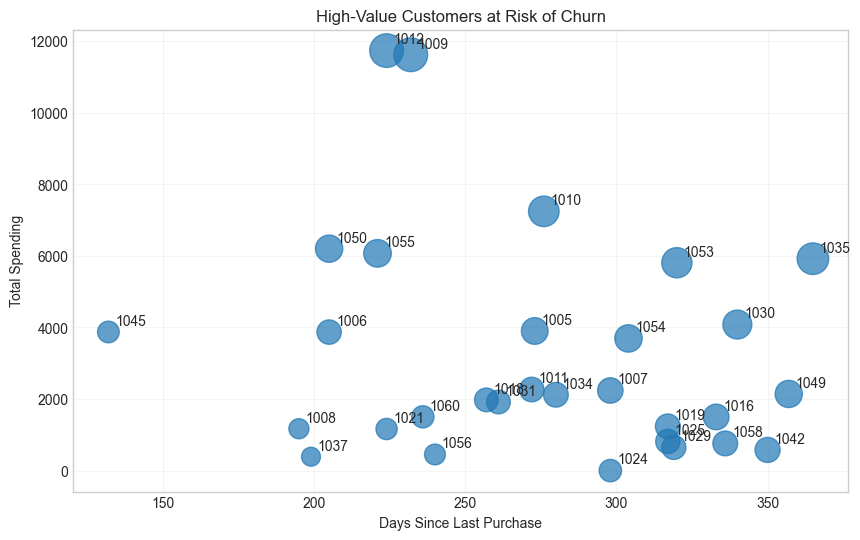

In [146]:
risk_df = customers[customers["risk_segment"] == "High Risk"].copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    risk_df["last_purchase_days"],
    risk_df["total_spending"],
    s=risk_df["retention_opportunity"] * 800,
    alpha=0.7
)

for _, row in risk_df.iterrows():
    plt.annotate(
        str(row["customer_id"]),
        (row["last_purchase_days"], row["total_spending"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.title("High-Value Customers at Risk of Churn")
plt.grid(alpha=0.2)
plt.savefig("charts/High-Value_Customers_at_Risk_of_Churn.png", dpi=300, bbox_inches="tight")
plt.show()

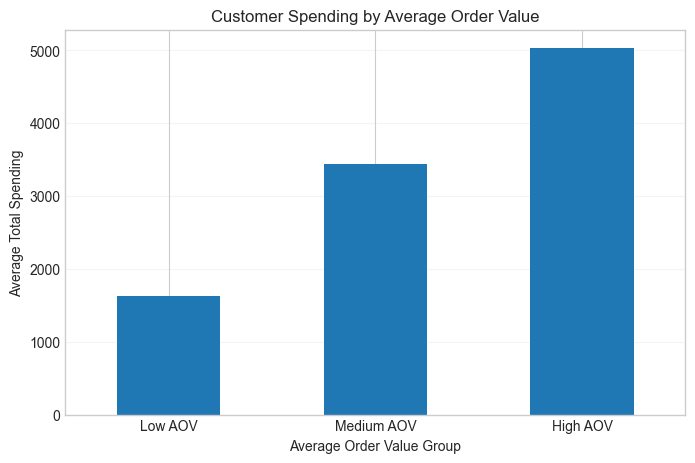

In [147]:
df["aov_group"] = pd.qcut(
    df["avg_order_value"],
    q=3,
    labels=["Low AOV", "Medium AOV", "High AOV"]
)

aov_summary = (
    df.groupby("aov_group", observed=True)["total_spending"]
      .mean()
)

plt.figure(figsize=(8, 5))
aov_summary.plot(kind="bar")

plt.xlabel("Average Order Value Group")
plt.ylabel("Average Total Spending")
plt.title("Customer Spending by Average Order Value")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.savefig("charts/Customer_Spending_by_Average_Order_Value.png", dpi=300, bbox_inches="tight")
plt.show()

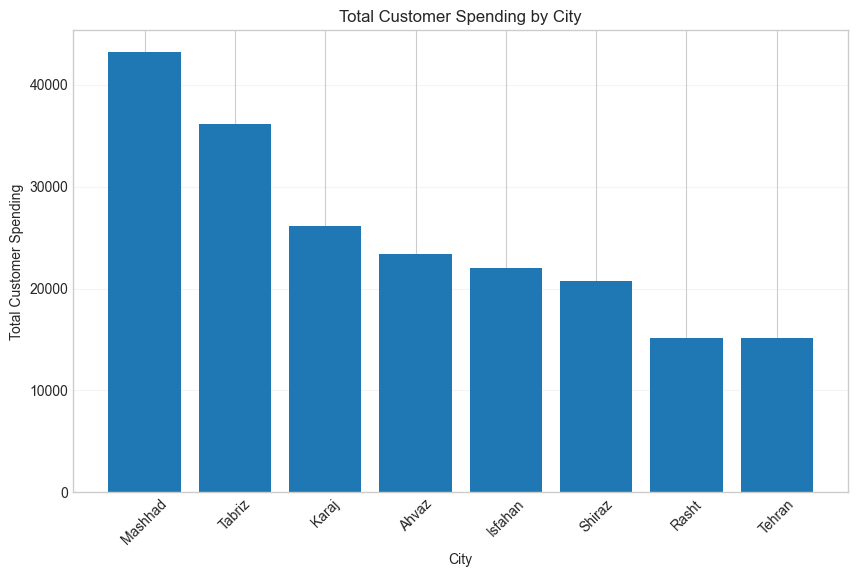

In [148]:
city_summary = (
    df.groupby("city")
      .agg(
          customers=("customer_id", "count"),
          total_revenue=("total_spending", "sum"),
          avg_spending=("total_spending", "mean")
      )
      .sort_values("total_revenue", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    city_summary.index,
    city_summary["total_revenue"]
)

plt.xlabel("City")
plt.ylabel("Total Customer Spending")
plt.title("Total Customer Spending by City")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.savefig("charts/Total_Customer_Spending_by_City.png", dpi=300, bbox_inches="tight")
plt.show()